# Notebook 3 — Merging IOA/Vitals, Medical, and Administrative Records

## Purpose

This notebook assembles the three data sources collected at Bordeaux University Hospital (Pellegrin site) into a single analysis-ready dataset for the ED patient clustering project. It covers data linkage quality assessment, investigation of missing records, and final export of both a full and a tabular version of the merged dataset.

---

## Pipeline Overview

### 1. Data loading & NDA harmonisation
Three CSV files are loaded: `df_ioa` (IOA + vital signs), `df_med` (medical records), and `df_admin` (administrative data). Patient identifiers (`nda`) are standardised across sources (removal of trailing `.0`, leading zeros, and whitespace) to ensure consistent linkage.

### 2. Merge quality audit
Full outer and pairwise merges are performed to quantify record overlap across all three sources. A flowchart-style report tracks the number of patients present at each step of the inclusion pipeline (Admin → Admin ∩ IOA → Admin ∩ IOA ∩ Med).

### 3. Investigation of missing records
Patients with an IOA record but no matching medical file — and vice versa — are characterised in depth:
- **Temporal distribution** of missingness over the 2022–2023 period
- **Chief complaint profile** of missing patients, with progressive exclusion of ophthalmology and ENT-specific motifs (expected to be routed outside the main ED pathway)
- **Administrative profile** of patients absent from both IOA and medical sources, with analysis of `mode_sortie_chu` and time-to-death — suggesting that a large fraction are resuscitation patients with very short stays
- **Chi² test + Cramér's V** to assess whether the chief complaint distribution of missing patients differs significantly from the full cohort (result: weak bias, V ≈ 0.13)

### 4. Final merge & EKG mining
An inner merge on all three sources retains only complete records. On the merged dataset, EKG mentions are extracted from free-text clinical fields using a two-step strategy: regex detection followed by fuzzy matching (RapidFuzz) on undetected records. A binary `had_ekg` flag is added to each patient row and an audit CSV is exported.

### 5. Post-merge quality checks
- Date consistency between the three admission date fields
- Age validation: declared age vs. age calculated from date of birth (discrepancies are retained rather than corrected, as unknown patients frequently have placeholder birth dates on arrival)

### 6. Export
Two output files are saved:
- `df_ioa_vital_med_adm_full.csv` — full merged dataset including free-text columns
- `df_ioa_vital_med_adm_tabular.csv` — tabular subset with narrative columns removed, ready for downstream preprocessing and clustering

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style"
) ### STOP WARNINGS OPENPYXL

In [ ]:
#!pip install rapidfuzz
import pandas as pd
import numpy as np
import re
from rapidfuzz import fuzz
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from rapidfuzz import fuzz
from scipy.stats import chi2_contingency


In [142]:


# ============================================================
# 1. LOADING FILES
# ============================================================
# Force 'nda' to string to avoid type mismatch during merges
df_med = pd.read_csv('Datasets/df_med_2022_2023.csv', dtype={'nda': str})
df_ioa = pd.read_csv('Datasets/df_ioafile_paramvit_clean_2022_2023.csv', dtype={'nda': str})
df_admin = pd.read_csv('Datasets/df_admin_2022_2023.csv', dtype={'nda': str})

# ============================================================
# Strict NDA cleaning (removes .0, spaces, leading zeros)
# ============================================================
def clean_nda(series):
    return (
        series.astype(str)
              .str.replace(r'\.0$', '', regex=True)
              .str.strip()
              .str.lstrip('0')
    )

print("🔧 Cleaning NDA formats...")
df_med['nda'] = clean_nda(df_med['nda'])
df_ioa['nda'] = clean_nda(df_ioa['nda'])

# ============================================================
# 2. FULL OUTER MERGE
# ============================================================
# Full merge to identify orphan records
df_merged = pd.merge(
    df_ioa,
    df_med,
    on='nda',
    how='outer',
    indicator='merge_check'
)

# ============================================================
# 3. MERGE QUALITY REPORT
# ============================================================
stats = df_merged['merge_check'].value_counts()

mapping_bilan = {
    'both': '✅ Complete record (IOA + Medical)',
    'left_only': '⚠️ IOA only (No medical record)',
    'right_only': '⚠️ Medical only (No IOA record)'
}

bilan_df = pd.DataFrame({
    'Number of records': stats.values,
    'Percentage (%)': (stats.values / len(df_merged) * 100).round(2)
}, index=stats.index.map(mapping_bilan))

print("📊 FULL MERGE QUALITY REPORT")
print("-" * 50)
display(bilan_df)
print("-" * 50)

# ============================================================
# 4. EXPORT ANOMALY COUNTS
# ============================================================
missing_med_count = len(df_merged[df_merged['merge_check'] == 'left_only'])
missing_ioa_count = len(df_merged[df_merged['merge_check'] == 'right_only'])

print(f"Total merged rows: {len(df_merged)}")
print(f"Patients without medical record: {missing_med_count}")
print(f"Patients with medical record but no IOA entry: {missing_ioa_count}")


🔧 Cleaning NDA formats...
📊 FULL MERGE QUALITY REPORT
--------------------------------------------------


,Number of records,Percentage (%)
merge_check,,
✅ Complete record (IOA + Medical),57391,68.82
⚠️ IOA only (No medical record),23104,27.70
⚠️ Medical only (No IOA record),2898,3.48


--------------------------------------------------
Total merged rows: 83393
Patients without medical record: 23104
Patients with medical record but no IOA entry: 2898


In [143]:
# ============================================================
# FLOWCHART DATA — ADMIN → IOA → MED
# ============================================================

# ── Nettoyage NDA admin ───────────────────────────────────
df_admin_clean = df_admin.copy()
df_admin_clean['nda'] = clean_nda(df_admin_clean['nda'])

nda_admin = set(df_admin_clean['nda'])
nda_ioa   = set(df_ioa['nda'])
nda_med   = set(df_med['nda'])

# ── Étape 1 : ADMIN ───────────────────────────────────────
n_admin = len(nda_admin)

# ── Étape 2 : ADMIN ∩ IOA ─────────────────────────────────
nda_admin_ioa     = nda_admin & nda_ioa
n_admin_ioa       = len(nda_admin_ioa)
n_lost_admin_ioa  = n_admin - n_admin_ioa          # dans admin mais pas dans IOA
n_ioa_not_admin   = len(nda_ioa - nda_admin)       # dans IOA mais pas dans admin

# ── Étape 3 : ADMIN ∩ IOA ∩ MED ──────────────────────────
nda_all_three         = nda_admin_ioa & nda_med
n_all_three           = len(nda_all_three)
n_lost_ioa_med        = n_admin_ioa - n_all_three  # dans admin+IOA mais pas dans med
n_med_not_admin_ioa   = len(nda_med - nda_admin_ioa)  # dans med mais pas dans admin+IOA

# ── Affichage flowchart ───────────────────────────────────
print("=" * 60)
print("FLOWCHART — PATIENT INCLUSION PIPELINE")
print("=" * 60)

print(f"\n┌─────────────────────────────────────┐")
print(f"│  ADMIN                              │")
print(f"│  N = {n_admin:,}                        │")
print(f"└─────────────────────────────────────┘")
print(f"           │")
print(f"           │ Excluded (in admin, not in IOA) : -{n_lost_admin_ioa:,}")
print(f"           │ In IOA but not in admin         : +{n_ioa_not_admin:,} (not included)")
print(f"           ▼")
print(f"┌─────────────────────────────────────┐")
print(f"│  ADMIN ∩ IOA                        │")
print(f"│  N = {n_admin_ioa:,}                        │")
print(f"└─────────────────────────────────────┘")
print(f"           │")
print(f"           │ Excluded (in admin+IOA, not in med) : -{n_lost_ioa_med:,}")
print(f"           │ In med but not in admin+IOA         : +{n_med_not_admin_ioa:,} (not included)")
print(f"           ▼")
print(f"┌─────────────────────────────────────┐")
print(f"│  ADMIN ∩ IOA ∩ MED                  │")
print(f"│  N = {n_all_three:,}                        │")
print(f"└─────────────────────────────────────┘")

FLOWCHART — PATIENT INCLUSION PIPELINE

┌─────────────────────────────────────┐
│  ADMIN                              │
│  N = 90,525                        │
└─────────────────────────────────────┘
           │
           │ Excluded (in admin, not in IOA) : -10,058
           │ In IOA but not in admin         : +28 (not included)
           ▼
┌─────────────────────────────────────┐
│  ADMIN ∩ IOA                        │
│  N = 80,467                        │
└─────────────────────────────────────┘
           │
           │ Excluded (in admin+IOA, not in med) : -23,078
           │ In med but not in admin+IOA         : +2,900 (not included)
           ▼
┌─────────────────────────────────────┐
│  ADMIN ∩ IOA ∩ MED                  │
│  N = 57,389                        │
└─────────────────────────────────────┘


In [144]:
# ============================================================
# MERGE QUALITY REPORT — FULL PIPELINE
# ============================================================

# ── Taille de base de chaque source ───────────────────────
print("📦 TAILLE DES SOURCES")
print("-" * 50)
print(f"df_admin  : {df_admin['nda'].nunique():,} NDA uniques ({len(df_admin):,} lignes)")
print(f"df_ioa    : {df_ioa['nda'].nunique():,} NDA uniques ({len(df_ioa):,} lignes)")
print(f"df_med    : {df_med['nda'].nunique():,} NDA uniques ({len(df_med):,} lignes)")

# ── Admin → IOA ───────────────────────────────────────────
print("\n📊 ADMIN → IOA")
print("-" * 50)
nda_admin = set(clean_nda(df_admin['nda']))
nda_ioa   = set(df_ioa['nda'])

in_both_admin_ioa    = nda_admin & nda_ioa
in_admin_not_ioa     = nda_admin - nda_ioa
in_ioa_not_admin     = nda_ioa - nda_admin

print(f"✅ Dans admin ET ioa        : {len(in_both_admin_ioa):,}")
print(f"⚠️  Dans admin, pas dans ioa : {len(in_admin_not_ioa):,} ({100*len(in_admin_not_ioa)/len(nda_admin):.1f}%)")
print(f"⚠️  Dans ioa, pas dans admin : {len(in_ioa_not_admin):,} ({100*len(in_ioa_not_admin)/len(nda_ioa):.1f}%)")

# ── IOA → Med ─────────────────────────────────────────────
print("\n📊 IOA → MED")
print("-" * 50)
nda_med = set(df_med['nda'])

in_both_ioa_med  = nda_ioa & nda_med
in_ioa_not_med   = nda_ioa - nda_med
in_med_not_ioa   = nda_med - nda_ioa

print(f"✅ Dans ioa ET med          : {len(in_both_ioa_med):,}")
print(f"⚠️  Dans ioa, pas dans med  : {len(in_ioa_not_med):,} ({100*len(in_ioa_not_med)/len(nda_ioa):.1f}%)")
print(f"⚠️  Dans med, pas dans ioa  : {len(in_med_not_ioa):,} ({100*len(in_med_not_ioa)/len(nda_med):.1f}%)")

# ── Pipeline complet admin → IOA → Med ───────────────────
print("\n📊 PIPELINE COMPLET ADMIN → IOA → MED")
print("-" * 50)
in_all_three       = nda_admin & nda_ioa & nda_med
in_admin_ioa_only  = nda_admin & nda_ioa - nda_med
in_admin_only      = nda_admin - nda_ioa - nda_med

print(f"✅ Dans les 3 sources                    : {len(in_all_three):,} ({100*len(in_all_three)/len(nda_admin):.1f}%)")
print(f"⚠️  Admin + IOA mais pas med             : {len(in_admin_ioa_only):,} ({100*len(in_admin_ioa_only)/len(nda_admin):.1f}%)")
print(f"❌ Admin seulement (ni IOA ni med)       : {len(in_admin_only):,} ({100*len(in_admin_only)/len(nda_admin):.1f}%)")

# ── Med → Admin ───────────────────────────────────────────
print("\n📊 MED → ADMIN")
print("-" * 50)
in_med_not_admin = nda_med - nda_admin
in_both_med_admin = nda_med & nda_admin
in_admin_not_med = nda_admin - nda_med
print(f"⚠️  Dans admin, pas dans med : {len(in_admin_not_med):,} ({100*len(in_admin_not_med)/len(nda_admin):.1f}%)")
print(f"✅ Dans med ET admin        : {len(in_both_med_admin):,} ({100*len(in_both_med_admin)/len(nda_med):.1f}%)")
print(f"⚠️  Dans med, pas dans admin : {len(in_med_not_admin):,} ({100*len(in_med_not_admin)/len(nda_med):.1f}%)")

📦 TAILLE DES SOURCES
--------------------------------------------------
df_admin  : 90,525 NDA uniques (90,525 lignes)
df_ioa    : 80,495 NDA uniques (80,495 lignes)
df_med    : 60,289 NDA uniques (60,289 lignes)

📊 ADMIN → IOA
--------------------------------------------------
✅ Dans admin ET ioa        : 80,467
⚠️  Dans admin, pas dans ioa : 10,058 (11.1%)
⚠️  Dans ioa, pas dans admin : 28 (0.0%)

📊 IOA → MED
--------------------------------------------------
✅ Dans ioa ET med          : 57,391
⚠️  Dans ioa, pas dans med  : 23,104 (28.7%)
⚠️  Dans med, pas dans ioa  : 2,898 (4.8%)

📊 PIPELINE COMPLET ADMIN → IOA → MED
--------------------------------------------------
✅ Dans les 3 sources                    : 57,389 (63.4%)
⚠️  Admin + IOA mais pas med             : 23,078 (25.5%)
❌ Admin seulement (ni IOA ni med)       : 7,162 (7.9%)

📊 MED → ADMIN
--------------------------------------------------
⚠️  Dans admin, pas dans med : 30,240 (33.4%)
✅ Dans med ET admin        : 60,285 (10

### Investigation of patient records with IOA but no medical record (potentially lost for clustering) or the opposite (medical record but no IOA° ###

In [145]:


# ============================================================
# 1. HARMONIZATION AND MERGE
# ============================================================
# Ensure NDA formats match before merging
df_ioa['nda'] = (
    df_ioa['nda'].astype(str)
                       .str.replace(r'\.0$', '', regex=True)
                       .str.strip()
                       .str.lstrip('0')
)

df_med['nda'] = (
    df_med['nda'].astype(str)
                 .str.replace(r'\.0$', '', regex=True)
                 .str.strip()
                 .str.lstrip('0')
)

df_diag = pd.merge(
    df_ioa,
    df_med,
    on='nda',
    how='left',
    indicator='merge_check'
)

# ============================================================
# 2. FILTER IOA-ONLY RECORDS
# ============================================================
# Keep only rows with no matching medical record
perdus = df_diag[df_diag['merge_check'] == 'left_only'].copy()

# ============================================================
# 3. DATE PREPARATION
# ============================================================
# Ensure date column is properly formatted
perdus['date_adm_final'] = pd.to_datetime(perdus['date_adm_final'])
perdus['mois'] = perdus['date_adm_final'].dt.to_period('M')

# ============================================================
# 4. MONTHLY DISTRIBUTION OF MISSING MEDICAL RECORDS
# ============================================================
print("📅 MONTHLY DISTRIBUTION OF PATIENTS WITHOUT MEDICAL RECORD")
print("-" * 60)

repartition_perte = perdus['mois'].value_counts().sort_index()
total_perte = len(perdus)

df_repartition = pd.DataFrame({
    'Missing Patients Count': repartition_perte,
    '% of Total Missing': ((repartition_perte / total_perte) * 100).round(1)
})

display(df_repartition)

# ============================================================
# 5. COMPARISON WITH TOTAL MONTHLY VOLUME
# ============================================================
print("\n💡 ANALYSIS:")

# Compare missing rate to total IOA volume per month
volume_global = (
    df_ioa['date_adm_final']
    .astype('datetime64[ns]')
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

taux_perte_mensuel = (repartition_perte / volume_global * 100).round(1)

print("Missing rate relative to total monthly volume:")
print(taux_perte_mensuel)


📅 MONTHLY DISTRIBUTION OF PATIENTS WITHOUT MEDICAL RECORD
------------------------------------------------------------


,Missing Patients Count,% of Total Missing
mois,,
2022-01,979,4.2
2022-02,985,4.3
2022-03,1105,4.8
2022-04,1231,5.3
2022-05,993,4.3
2022-06,853,3.7
2022-07,944,4.1
2022-08,970,4.2
2022-09,905,3.9



💡 ANALYSIS:
Missing rate relative to total monthly volume:
mois
2022-01    25.2
2022-02    27.9
2022-03    26.2
2022-04    30.8
2022-05    28.3
2022-06    26.4
2022-07    28.3
2022-08    28.5
2022-09    26.7
2022-10    28.8
2022-11    27.8
2022-12    27.5
2023-01    25.9
2023-02    30.1
2023-03    28.9
2023-04    35.2
2023-05    27.9
2023-06    32.4
2023-07    33.4
2023-08    30.8
2023-09    28.2
2023-10    26.9
2023-11    27.7
2023-12    29.8
Freq: M, Name: count, dtype: float64


In [146]:
# ============================================================
# ADMIN PROFILE — patients without IOA record
# ============================================================

# Patients in medical but not in IOA
missing_ioa = df_merged[df_merged['merge_check'] == 'right_only'][['nda']].copy()

# Merge with admin
missing_ioa_admin = missing_ioa.merge(df_admin, on='nda', how='left')

print(f"N patients without IOA matched to admin: {missing_ioa_admin['nda'].nunique()}")
print(f"Admin records found: {missing_ioa_admin.shape[0]}")
print()

# Aperçu des colonnes disponibles
print("Colonnes admin disponibles :")
print(missing_ioa_admin.columns.tolist())
print()

# Aperçu général
display(missing_ioa_admin.head(100))

N patients without IOA matched to admin: 2898
Admin records found: 2898

Colonnes admin disponibles :
['nda', 'uam_service', 'date_naissance', 'date_entree_urg', 'date_sortie_urg', 'date_sortie_urg_completee', 'decision_urgence', 'date_sortie_chu', 'mode_sortie_chu']



,nda,uam_service,date_naissance,date_entree_urg,date_sortie_urg,date_sortie_urg_completee,decision_urgence,date_sortie_chu,mode_sortie_chu
0,22030011763,9780.0,2002/02/25 00:00:00,2022-01-01 09:53:00,2022/01/01 16:12:00,2022/01/01 09:54:00,Hospitalisation,2022/01/09 14:23:00,A - Domicile
1,22030011774,9780.0,1958/11/30 00:00:00,2022-01-01 10:20:00,2022/01/01 16:09:00,2022/01/01 10:22:00,Hospitalisation,2022/01/01 16:09:00,C1 - Transfert provisoire (<48h) MCO
2,22030011799,9780.0,1959/05/09 00:00:00,2022-01-01 11:19:00,2022/01/02 12:00:00,2022/01/01 11:24:00,Hospitalisation,2022/01/02 12:00:00,A - Domicile
3,22030011817,9780.0,1950/10/17 00:00:00,2022-01-01 12:04:00,2022/01/01 16:30:00,2022/01/01 12:05:00,Hospitalisation,2022/01/03 16:08:00,B1 - Transfert MCO
4,22030011877,9780.0,1940/10/15 00:00:00,2022-01-01 13:35:00,2022/01/04 10:00:00,2022/01/01 13:37:00,Hospitalisation,2022/01/04 10:00:00,B1 - Transfert MCO
...,...,...,...,...,...,...,...,...,...
95,22030054992,9780.0,1953/02/09 00:00:00,2022-01-13 09:29:00,2022/01/13 21:00:00,2022/01/13 11:00:00,Hospitalisation,2022/01/13 21:00:00,A - Domicile
96,22030056977,9780.0,1993/11/29 00:00:00,2022-01-13 13:18:00,2022/01/13 23:30:00,NaN,NaN,2022/01/13 23:30:00,A - Domicile
97,22030058811,9780.0,1931/04/18 00:00:00,2022-01-13 16:48:00,2022/01/13 22:21:00,NaN,Hospitalisation,2022/05/03 14:02:00,A - Domicile
98,22030058869,9780.0,1936/02/11 00:00:00,2022-01-13 17:14:00,2022/01/14 14:46:00,NaN,Hospitalisation,2022/02/28 15:40:00,A - Domicile


In [147]:
# ============================================================
# ADMIN — patients without ANY record (neither IOA nor medical)
# ============================================================

# NDAs présents dans admin
nda_admin = set(clean_nda(df_admin['nda']))

# NDAs présents dans ioa ou med
nda_ioa = set(df_ioa['nda'])
nda_med = set(df_med['nda'])
nda_ioa_or_med = nda_ioa | nda_med

# NDAs admin qui n'ont ni IOA ni médical
nda_orphan_admin = nda_admin - nda_ioa_or_med

print(f"Patients dans admin sans aucun dossier IOA ni médical : {len(nda_orphan_admin)}")

orphan_admin = df_admin[clean_nda(df_admin['nda']).isin(nda_orphan_admin)].copy()

print(f"Lignes admin correspondantes : {len(orphan_admin)}")
print()
display(orphan_admin.head(100))

# ============================================================
# EXPORT CSV — patients admin sans IOA ni dossier médical
# ============================================================

orphan_admin.to_csv('orphan_admin_no_ioa_no_med.csv', index=False)
print(f"Saved: orphan_admin_no_ioa_no_med.csv ({len(orphan_admin)} lignes)")

Patients dans admin sans aucun dossier IOA ni médical : 7162
Lignes admin correspondantes : 7162



,uam_service,nda,date_naissance,date_entree_urg,date_sortie_urg,date_sortie_urg_completee,decision_urgence,date_sortie_chu,mode_sortie_chu
32,9780,22030011702,1998/11/11 00:00:00,2022-01-01 05:52:00,2022/01/01 07:15:00,NaN,Hospitalisation,2022/01/05 18:00:00,A - Domicile
65,9780,22030011810,2001/07/10 00:00:00,2022-01-01 11:48:00,2022/01/01 20:16:00,2022/01/01 11:51:00,Hospitalisation,2022/01/11 15:52:00,A - Domicile
100,9780,22030011954,1945/09/02 00:00:00,2022-01-01 15:16:00,2022/01/02 13:30:00,NaN,Hospitalisation,2022/01/12 16:52:00,A - Domicile
123,9780,22030012035,1977/03/25 00:00:00,2022-01-01 18:03:00,2022/01/02 02:25:00,2022/01/02 02:25:00,Consultation,2022/01/02 02:25:00,NaN
143,9780,22030012114,2004/11/14 00:00:00,2022-01-01 21:24:00,2022/01/01 22:01:00,2022/01/01 22:01:00,Consultation,2022/01/01 22:01:00,NaN
...,...,...,...,...,...,...,...,...,...
1336,9780,22030041176,1997/06/20 00:00:00,2022-01-10 11:43:00,2022/01/10 12:30:00,2022/01/10 12:30:00,Consultation,2022/01/10 12:30:00,NaN
1337,9780,22030041258,2009/01/29 00:00:00,2022-01-10 11:52:00,2022/01/10 12:17:00,2022/01/10 15:38:00,Consultation,2022/01/10 15:38:00,NaN
1358,9780,22030041909,1990/07/28 00:00:00,2022-01-10 13:33:00,2022/01/10 14:36:00,2022/01/10 14:36:00,Consultation,2022/01/10 14:36:00,NaN
1394,9780,22030043991,1998/06/15 00:00:00,2022-01-10 17:25:00,2022/01/10 17:46:00,2022/01/10 17:46:00,Consultation,2022/01/10 17:46:00,NaN


Saved: orphan_admin_no_ioa_no_med.csv (7162 lignes)


In [148]:
# ============================================================
# REPARTITION MODE_SORTIE_CHU
# ============================================================

# Sur tous les patients admin
print("📊 Tous les patients admin :")
ms_all = df_admin['mode_sortie_chu'].value_counts()
ms_all_pct = (ms_all / len(df_admin) * 100).round(1)
df_ms_all = pd.DataFrame({'N': ms_all, '%': ms_all_pct})
display(df_ms_all)

# Sur les patients sans IOA ni médical
print(f"\n📊 Patients sans IOA ni dossier médical (n={len(orphan_admin)}) :")
ms_orphan = orphan_admin['mode_sortie_chu'].value_counts()
ms_orphan_pct = (ms_orphan / len(orphan_admin) * 100).round(1)
df_ms_orphan = pd.DataFrame({'N': ms_orphan, '%': ms_orphan_pct})
display(df_ms_orphan)

📊 Tous les patients admin :


,N,%
mode_sortie_chu,,
A - Domicile,37403,41.3
B1 - Transfert MCO,1698,1.9
B2 - Transfert SSR,1636,1.8
C0 - Décédé,1589,1.8
B4 - Transfert PSY,1226,1.4
C1 - Transfert provisoire (<48h) MCO,458,0.5
A2 - Fugue,101,0.1
B3 - Transfert Long Séjour,76,0.1
D2 - Mutation SSR,6,0.0



📊 Patients sans IOA ni dossier médical (n=7162) :


,N,%
mode_sortie_chu,,
A - Domicile,1978,27.6
B1 - Transfert MCO,505,7.1
C0 - Décédé,473,6.6
B2 - Transfert SSR,364,5.1
C1 - Transfert provisoire (<48h) MCO,218,3.0
B4 - Transfert PSY,59,0.8
B3 - Transfert Long Séjour,11,0.2
A2 - Fugue,9,0.1
D4 - Mutation PSY,1,0.0


In [149]:
# ============================================================
# DUREE ENTRE DATE_SORTIE_URGENCE ET DATE_SORTIE_CHU
# ============================================================

def compute_duree_sortie(df, label):
    df = df.copy()
    df['date_sortie_urg'] = pd.to_datetime(df['date_sortie_urg'], errors='coerce')
    df['date_sortie_chu']     = pd.to_datetime(df['date_sortie_chu'], errors='coerce')
    df['duree_sortie_h']      = (df['date_sortie_chu'] - df['date_sortie_urg']).dt.total_seconds() / 3600

    print(f"\n📊 {label} (n={len(df)}) :")
    print(df['duree_sortie_h'].describe().round(1))
    print(f"NaN (dates manquantes) : {df['duree_sortie_h'].isna().sum()}")
    return df

df_admin_duree   = compute_duree_sortie(df_admin, "Tous les patients admin")
orphan_admin_duree = compute_duree_sortie(orphan_admin, "Patients sans IOA ni dossier médical")


📊 Tous les patients admin (n=90525) :
count    90524.0
mean        58.6
std        289.5
min         -0.0
25%          0.0
50%          0.0
75%          0.0
max      13980.3
Name: duree_sortie_h, dtype: float64
NaN (dates manquantes) : 1

📊 Patients sans IOA ni dossier médical (n=7162) :
count     7161.0
mean       181.5
std        569.3
min          0.0
25%          0.0
50%          0.0
75%        136.0
max      13483.2
Name: duree_sortie_h, dtype: float64
NaN (dates manquantes) : 1


In [150]:
# ============================================================
# DUREE SORTIE — MODE_SORTIE_CHU == "C0 - décédé"
# ============================================================

def compute_duree_deces(df, label):
    df = df[df['mode_sortie_chu'] == 'C0 - Décédé'].copy()
    df['date_sortie_urg'] = pd.to_datetime(df['date_sortie_urg'], errors='coerce')
    df['date_sortie_chu']     = pd.to_datetime(df['date_sortie_chu'], errors='coerce')
    df['duree_sortie_h']      = (df['date_sortie_chu'] - df['date_sortie_urg']).dt.total_seconds() / 3600

    print(f"\n📊 {label} — décédés (n={len(df)}) :")
    print(df['duree_sortie_h'].describe().round(1))
    print(f"NaN (dates manquantes) : {df['duree_sortie_h'].isna().sum()}")
    return df

deces_all    = compute_duree_deces(df_admin, "Tous patients admin")
deces_orphan = compute_duree_deces(orphan_admin, "Patients sans IOA ni dossier médical")


📊 Tous patients admin — décédés (n=1589) :
count    1589.0
mean      266.1
std       568.3
min         0.0
25%         0.0
50%        77.8
75%       308.6
max      8632.8
Name: duree_sortie_h, dtype: float64
NaN (dates manquantes) : 0

📊 Patients sans IOA ni dossier médical — décédés (n=473) :
count     473.0
mean      206.8
std       531.5
min         0.0
25%         0.0
50%        55.0
75%       224.6
max      8632.8
Name: duree_sortie_h, dtype: float64
NaN (dates manquantes) : 0


Sur l'ensemble des patients décédés (n=1589)Sur l'ensemble des patients décédés (n=1589)
La durée médiane entre sortie des urgences et décès est de 77.8h (~3.2 jours). Le Q1 est à 0, ce qui signifie qu'au moins 25% des patients décèdent le jour même ou très rapidement après leur sortie des urgences. Le Q3 à 308h (~13 jours) montre une grande variabilité. Le max à 8632h (~360 jours) reflète des hospitalisations très longues avant le décès.

Sur les patients sans IOA ni dossier médical (n=473, soit ~30% des décédés)
La médiane est plus basse à 55h (~2.3 jours), et le Q3 à 224h (~9 jours). Ces patients décèdent donc plus rapidement que la population globale des décédés.

Interprétation
Le Q1 à 0 dans les deux groupes est le point le plus important — il suggère que beaucoup de ces patients décèdent aux urgences ou dans les heures qui suivent, ce qui peut expliquer en partie l'absence de dossier IOA ou médical : des passages très courts, des décès rapides à l'arrivée, ou des enregistrements incomplets dans des situations d'urgence extrême.  => **donc patient déchoc**

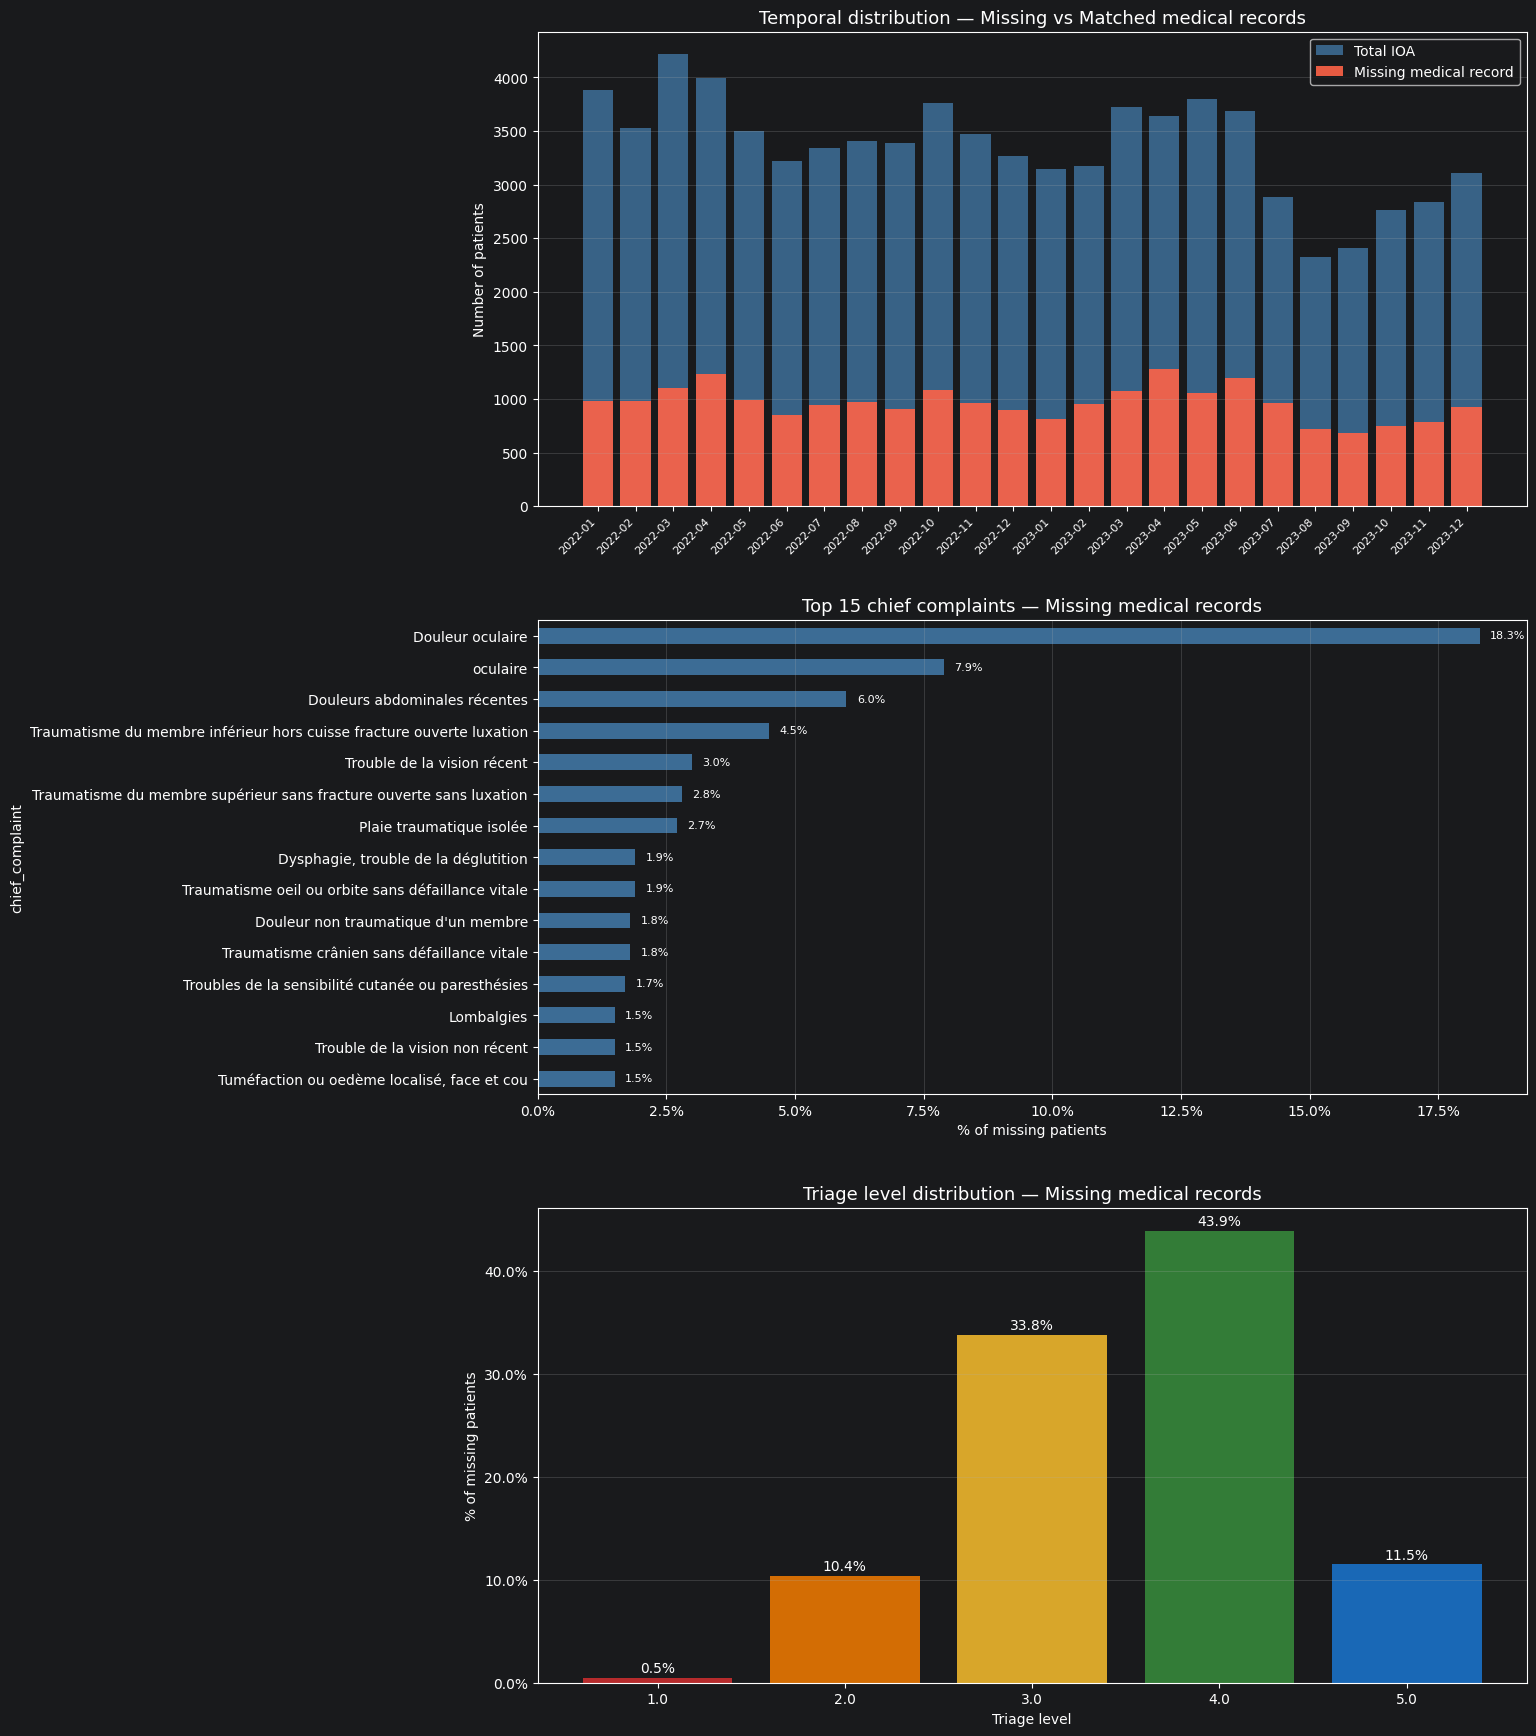

✅ Plot saved: missing_records_analysis.png


In [151]:


# ============================================================
# 1. TEMPORAL DISTRIBUTION (missing vs non-missing)
# ============================================================
df_ioa['mois'] = pd.to_datetime(df_ioa['date_adm_final']).dt.to_period('M')
perdus['mois'] = pd.to_datetime(perdus['date_adm_final']).dt.to_period('M')

volume_global   = df_ioa['mois'].value_counts().sort_index()
volume_perdus   = perdus['mois'].value_counts().sort_index()
volume_matches  = (volume_global - volume_perdus).fillna(volume_global)

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# --- Plot 1: Temporal distribution ---
ax1 = axes[0]
months = [str(m) for m in volume_global.index]
x = range(len(months))

ax1.bar(x, volume_global.values, label='Total IOA', color='steelblue', alpha=0.7)
ax1.bar(x, volume_perdus.reindex(volume_global.index, fill_value=0).values,
        label='Missing medical record', color='tomato', alpha=0.9)
ax1.set_xticks(list(x))
ax1.set_xticklabels(months, rotation=45, ha='right', fontsize=8)
ax1.set_title('Temporal distribution — Missing vs Matched medical records', fontsize=13)
ax1.set_ylabel('Number of patients')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Chief complaints ---
ax2 = axes[1]
cc_counts = (
    perdus['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts(normalize=True)
    .head(15)
    .mul(100)
    .round(1)
)
cc_counts.sort_values().plot(kind='barh', ax=ax2, color='steelblue', alpha=0.8)
ax2.set_title('Top 15 chief complaints — Missing medical records', fontsize=13)
ax2.set_xlabel('% of missing patients')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(cc_counts.sort_values().values):
    ax2.text(v + 0.2, i, f'{v}%', va='center', fontsize=8)

# --- Plot 3: Triage level ---
ax3 = axes[2]
triage_counts = (
    perdus['triage']
    .dropna()
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1976d2']
bars = ax3.bar(triage_counts.index.astype(str), triage_counts.values,
               color=colors[:len(triage_counts)], alpha=0.85)
ax3.set_title('Triage level distribution — Missing medical records', fontsize=13)
ax3.set_xlabel('Triage level')
ax3.set_ylabel('% of missing patients')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, triage_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=10)

plt.tight_layout(pad=3.0)
plt.savefig("missing_records_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: missing_records_analysis.png")

In [152]:
cc_full = (
    perdus['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

cc_full_df = pd.DataFrame({
    'Count': perdus['chief_complaint']
             .replace(['nan', 'None', '', 'Unknown'], pd.NA)
             .dropna()
             .value_counts(),
    'Percentage': cc_full
})

print(f"Total chief complaints distincts : {len(cc_full_df)}")
print(cc_full_df.to_string())

Total chief complaints distincts : 176
                                                                        Count  Percentage
chief_complaint                                                                          
Douleur oculaire                                                         4233        18.3
oculaire                                                                 1824         7.9
Douleurs abdominales récentes                                            1393         6.0
Traumatisme du membre inférieur hors cuisse fracture ouverte luxation    1041         4.5
Trouble de la vision récent                                               688         3.0
Traumatisme du membre supérieur sans fracture ouverte sans luxation       645         2.8
Plaie traumatique isolée                                                  613         2.7
Traumatisme oeil ou orbite sans défaillance vitale                        444         1.9
Dysphagie, trouble de la déglutition                         

Patients avec chief complaint ophtalmologique : 7,817
Patients restants après exclusion : 15,287

=== Chief complaints ophtalmologiques exclus ===
chief_complaint
Douleur oculaire                                      4233
oculaire                                              1824
Trouble de la vision récent                            688
Traumatisme oeil ou orbite sans défaillance vitale     444
Trouble de la vision non récent                        340
Traumatisme de la face sans atteinte ophtalmique       288

Total chief complaints distincts (sans ophtalmo) : 170
chief_complaint
Douleurs abdominales récentes                                             9.1
Traumatisme du membre inférieur hors cuisse fracture ouverte luxation     6.8
Traumatisme du membre supérieur sans fracture ouverte sans luxation       4.2
Plaie traumatique isolée                                                  4.0
Dysphagie, trouble de la déglutition                                      2.9
Douleur non traumatiq

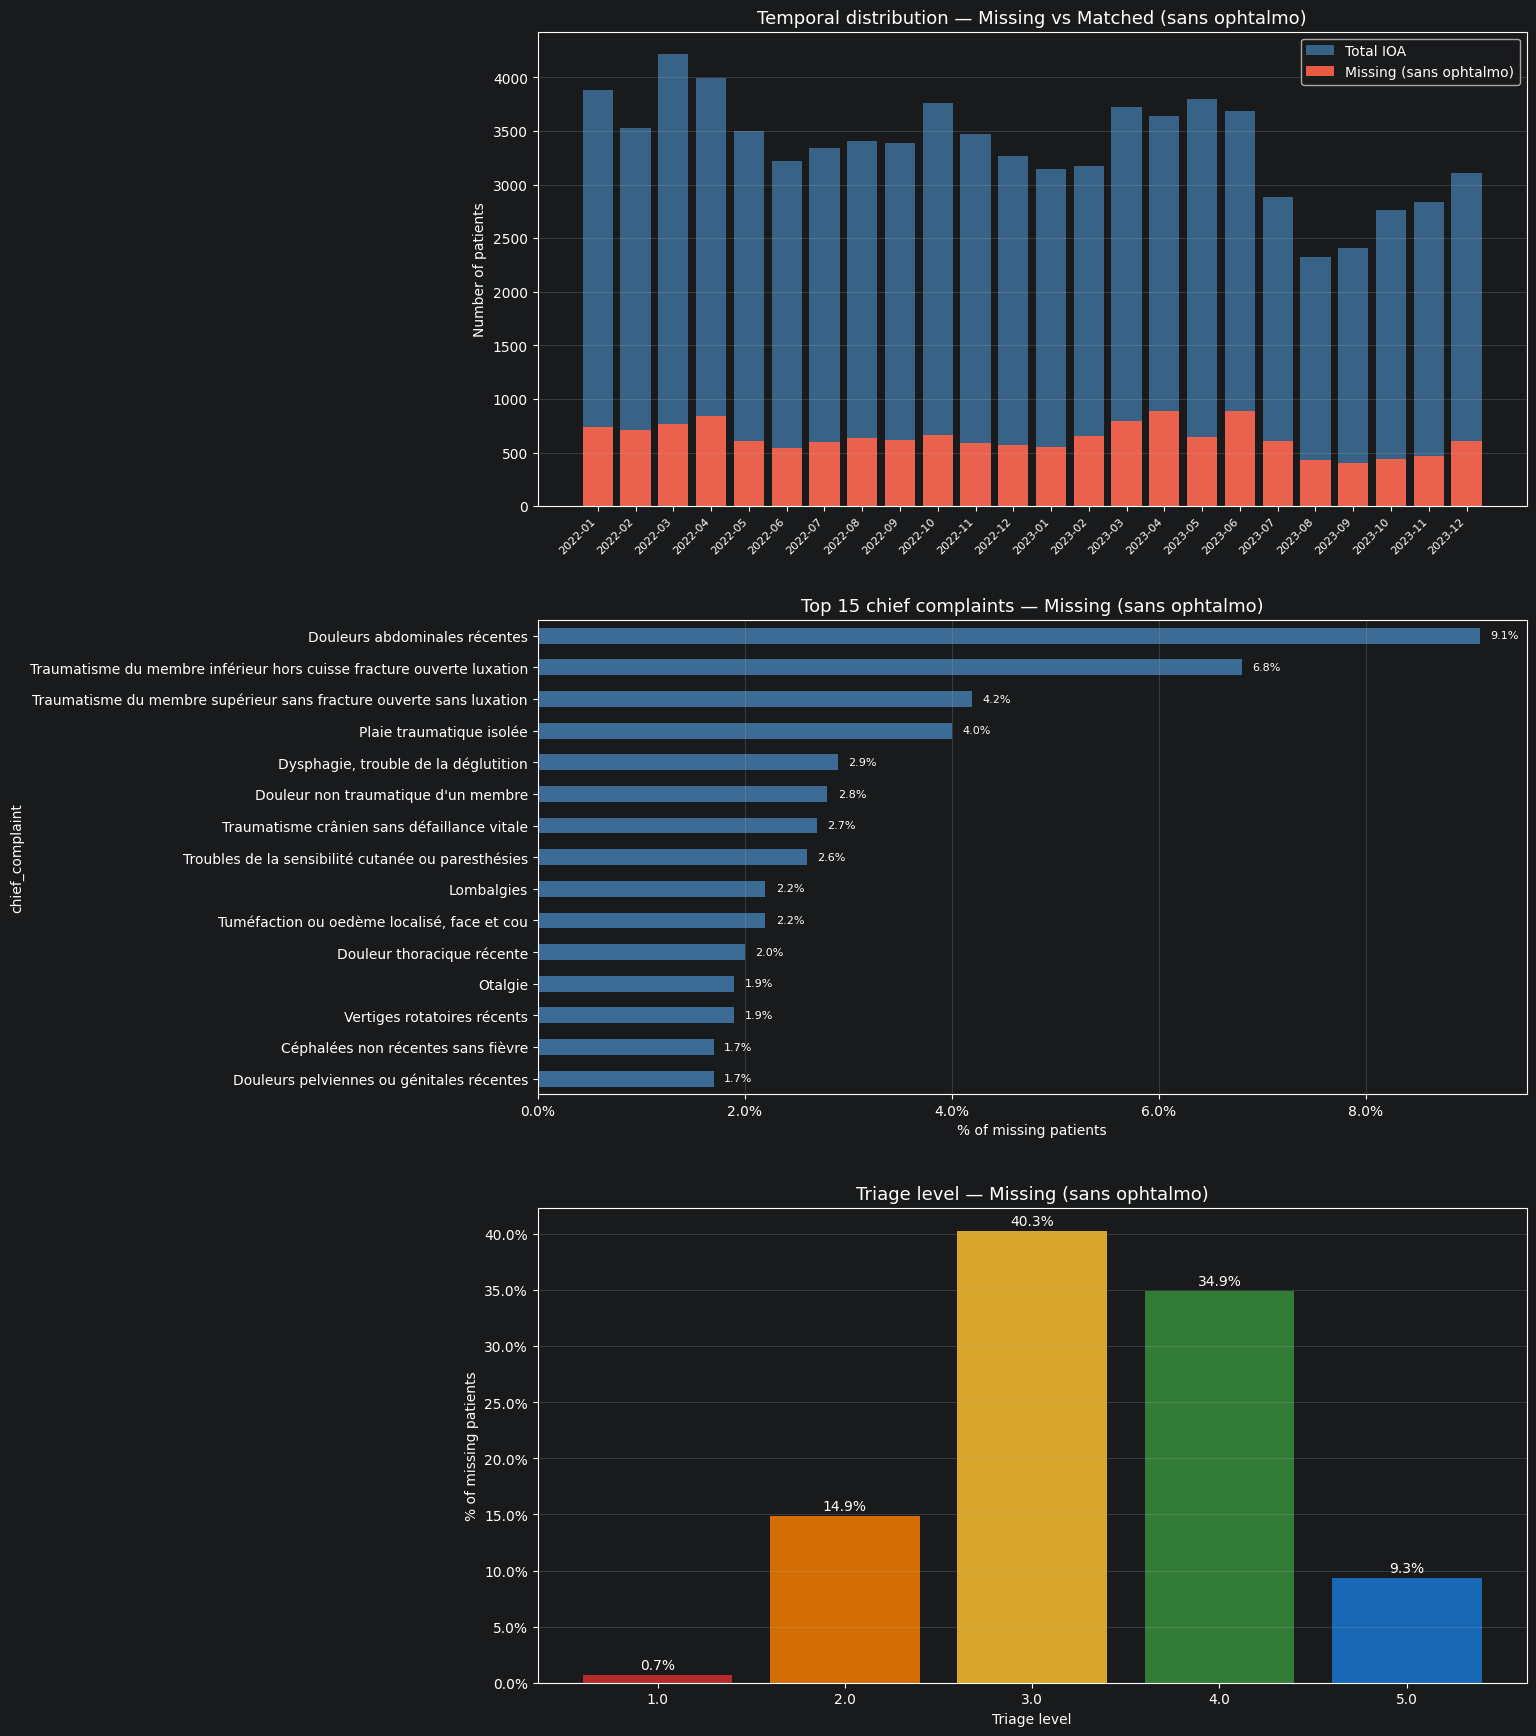

✅ Plot saved: missing_no_ophtalmo_analysis.png


In [153]:
# --- Mots clés ophtalmologie ---
ophtalmo_keywords = [
    "oculaire", "oeil", "yeux", "vision", "visuel", "orbite",
    "ophtalmique", "corps étranger.*oeil", "traumatisme.*oeil",
    "brûlure.*oculaire", "oculaire.*brûlure", "cécité"
]

pattern_ophtalmo = "|".join(ophtalmo_keywords)

# --- Masque sur les perdus ---
mask_ophtalmo = perdus['chief_complaint'].str.contains(
    pattern_ophtalmo, case=False, na=False, regex=True
)

print(f"Patients avec chief complaint ophtalmologique : {mask_ophtalmo.sum():,}")
print(f"Patients restants après exclusion : {(~mask_ophtalmo).sum():,}")

# --- Chief complaints exclus ---
print("\n=== Chief complaints ophtalmologiques exclus ===")
print(perdus[mask_ophtalmo]['chief_complaint'].value_counts().to_string())

# --- Nouveau dataframe sans ophtalmo ---
perdus_no_ophtalmo = perdus[~mask_ophtalmo].copy()

# --- Stats ---
cc_no_ophtalmo = (
    perdus_no_ophtalmo['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(f"\nTotal chief complaints distincts (sans ophtalmo) : {len(cc_no_ophtalmo)}")
print(cc_no_ophtalmo.to_string())

# --- Graphiques ---
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# Plot 1: Temporal
volume_global_no_oph = df_ioa['mois'].value_counts().sort_index()
volume_perdus_no_oph = perdus_no_ophtalmo['mois'].value_counts().sort_index()

months = [str(m) for m in volume_global_no_oph.index]
x = range(len(months))

axes[0].bar(x, volume_global_no_oph.values, label='Total IOA', color='steelblue', alpha=0.7)
axes[0].bar(x, volume_perdus_no_oph.reindex(volume_global_no_oph.index, fill_value=0).values,
            label='Missing (sans ophtalmo)', color='tomato', alpha=0.9)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(months, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Temporal distribution — Missing vs Matched (sans ophtalmo)', fontsize=13)
axes[0].set_ylabel('Number of patients')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Top 15 chief complaints
cc_top15 = cc_no_ophtalmo.head(15).sort_values()
cc_top15.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Top 15 chief complaints — Missing (sans ophtalmo)', fontsize=13)
axes[1].set_xlabel('% of missing patients')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(cc_top15.values):
    axes[1].text(v + 0.1, i, f'{v}%', va='center', fontsize=8)

# Plot 3: Triage
triage_counts = (
    perdus_no_ophtalmo['triage']
    .dropna()
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1976d2']
bars = axes[2].bar(triage_counts.index.astype(str), triage_counts.values,
                   color=colors[:len(triage_counts)], alpha=0.85)
axes[2].set_title('Triage level — Missing (sans ophtalmo)', fontsize=13)
axes[2].set_xlabel('Triage level')
axes[2].set_ylabel('% of missing patients')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, triage_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontsize=10)

plt.tight_layout(pad=3.0)
plt.savefig("missing_no_ophtalmo_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: missing_no_ophtalmo_analysis.png")

=== COMPARISON : Missing vs Full dataset ===
                                                                        Missing (%)  Full dataset (%)  Diff (Missing - Full)
chief_complaint                                                                                                             
Dysphagie, trouble de la déglutition                                            2.9               1.8                    1.1
Plaie traumatique isolée                                                        4.0               3.0                    1.0
Tuméfaction ou oedème localisé, face et cou                                     2.2               1.3                    0.9
Problème avec dispositif médical/sonde/stomie                                   1.3               0.6                    0.7
Epistaxis, otorragie, ou autre saignement ORL                                   1.5               0.9                    0.6
opératoire                                                                      

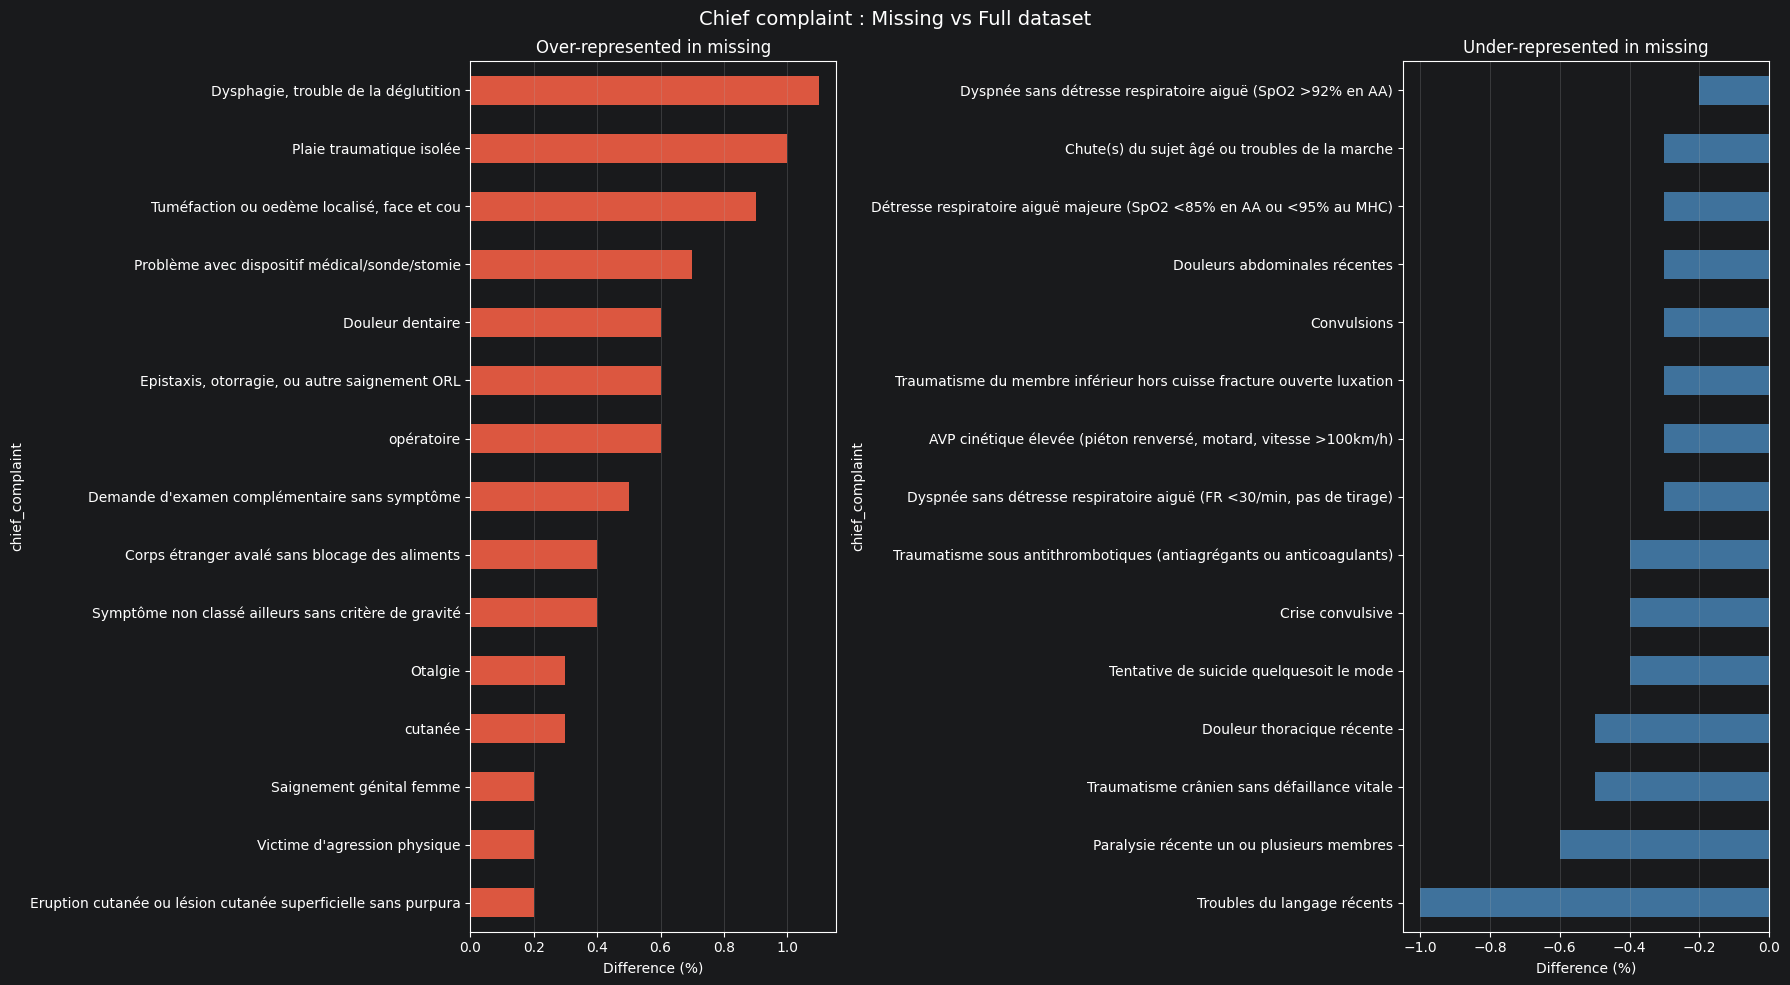

In [154]:
# 1. Full dataset sans ophtalmo
mask_ophtalmo_full = df_ioa['chief_complaint'].str.contains(
    pattern_ophtalmo, case=False, na=False, regex=True
)

cc_full_dataset = (
    df_ioa[~mask_ophtalmo_full]['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# 2. Missing sans ophtalmo
cc_missing = cc_no_ophtalmo

# 3. Merge
df_compare = pd.DataFrame({
    'Missing (%)': cc_missing,
    'Full dataset (%)': cc_full_dataset
}).fillna(0)

df_compare['Diff (Missing - Full)'] = (
    df_compare['Missing (%)'] - df_compare['Full dataset (%)']
).round(1)

df_compare = df_compare.sort_values('Diff (Missing - Full)', ascending=False)

print("=== COMPARISON : Missing vs Full dataset ===")
print(df_compare.to_string())

# --- Graphique ---
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

top_over = df_compare.head(15)
top_over['Diff (Missing - Full)'].sort_values().plot(
    kind='barh', ax=axes[0], color='tomato', alpha=0.85
)
axes[0].set_title('Over-represented in missing', fontsize=12)
axes[0].set_xlabel('Difference (%)')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

top_under = df_compare.tail(15)
top_under['Diff (Missing - Full)'].sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', alpha=0.85
)
axes[1].set_title('Under-represented in missing', fontsize=12)
axes[1].set_xlabel('Difference (%)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Chief complaint : Missing vs Full dataset', fontsize=14)
plt.tight_layout()
plt.savefig("comparison_missing_vs_full.png", dpi=150, bbox_inches='tight')
plt.show()

In [155]:
# --- Mots clés ORL ---
orl_keywords = [
    "otalgie", "otite", "epistaxis", "otorragie", "orl",
    "gorge", "angine", "stomatite", "dysphagie", "déglutition",
    "tuméfaction.*cerv", "cerv.*tuméfaction",
    "obstruction nasale", "rhinite", "sinusite", "rhinorrhée",
    "laryngite", "trachéite", "audition", "acouphène",
    "corps étranger orl", "tuméfaction orl",
    "oreille", "auriculaire", "facial.*oreille", "oreille.*facial"
]

pattern_orl = "|".join(orl_keywords)

# --- Vérification ce qu'on va exclure ---
mask_orl = perdus_no_ophtalmo['chief_complaint'].str.contains(
    pattern_orl, case=False, na=False, regex=True
)

print(f"Patients avec chief complaint ORL : {mask_orl.sum():,}")
print("\n=== Chief complaints ORL exclus ===")
print(perdus_no_ophtalmo[mask_orl]['chief_complaint'].value_counts().to_string())

Patients avec chief complaint ORL : 1,115

=== Chief complaints ORL exclus ===
chief_complaint
Dysphagie, trouble de la déglutition             436
Otalgie                                          285
Epistaxis, otorragie, ou autre saignement ORL    228
auriculaire                                       68
Troubles de l'audition                            67
Traumatisme de l'oreille                          20
Obstruction nasale et rhinorrhée                  10
Laryngite et trachéite                             1


In [156]:
# --- Exclusion ORL ---
perdus_no_oph_orl = perdus_no_ophtalmo[~mask_orl].copy()

print(f"=== RÉSUMÉ DES EXCLUSIONS ===")
print(f"Perdus initial                    : {len(perdus):,}")
print(f"- Ophtalmo exclus                 : {mask_ophtalmo.sum():,}")
print(f"- ORL exclus                      : {mask_orl.sum():,}")
print(f"Perdus restants                   : {len(perdus_no_oph_orl):,}")

print(f"\n=== CHIEF COMPLAINTS RESTANTS ===")
cc_restants = (
    perdus_no_oph_orl['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts()
)
print(f"Chief complaints distincts : {len(cc_restants)}")
print(cc_restants.to_string())

=== RÉSUMÉ DES EXCLUSIONS ===
Perdus initial                    : 23,104
- Ophtalmo exclus                 : 7,817
- ORL exclus                      : 1,115
Perdus restants                   : 14,172

=== CHIEF COMPLAINTS RESTANTS ===
Chief complaints distincts : 162
chief_complaint
Douleurs abdominales récentes                                             1393
Traumatisme du membre inférieur hors cuisse fracture ouverte luxation     1041
Traumatisme du membre supérieur sans fracture ouverte sans luxation        645
Plaie traumatique isolée                                                   613
Douleur non traumatique d'un membre                                        424
Traumatisme crânien sans défaillance vitale                                420
Troubles de la sensibilité cutanée ou paresthésies                         393
Lombalgies                                                                 339
Tuméfaction ou oedème localisé, face et cou                                335
Doule

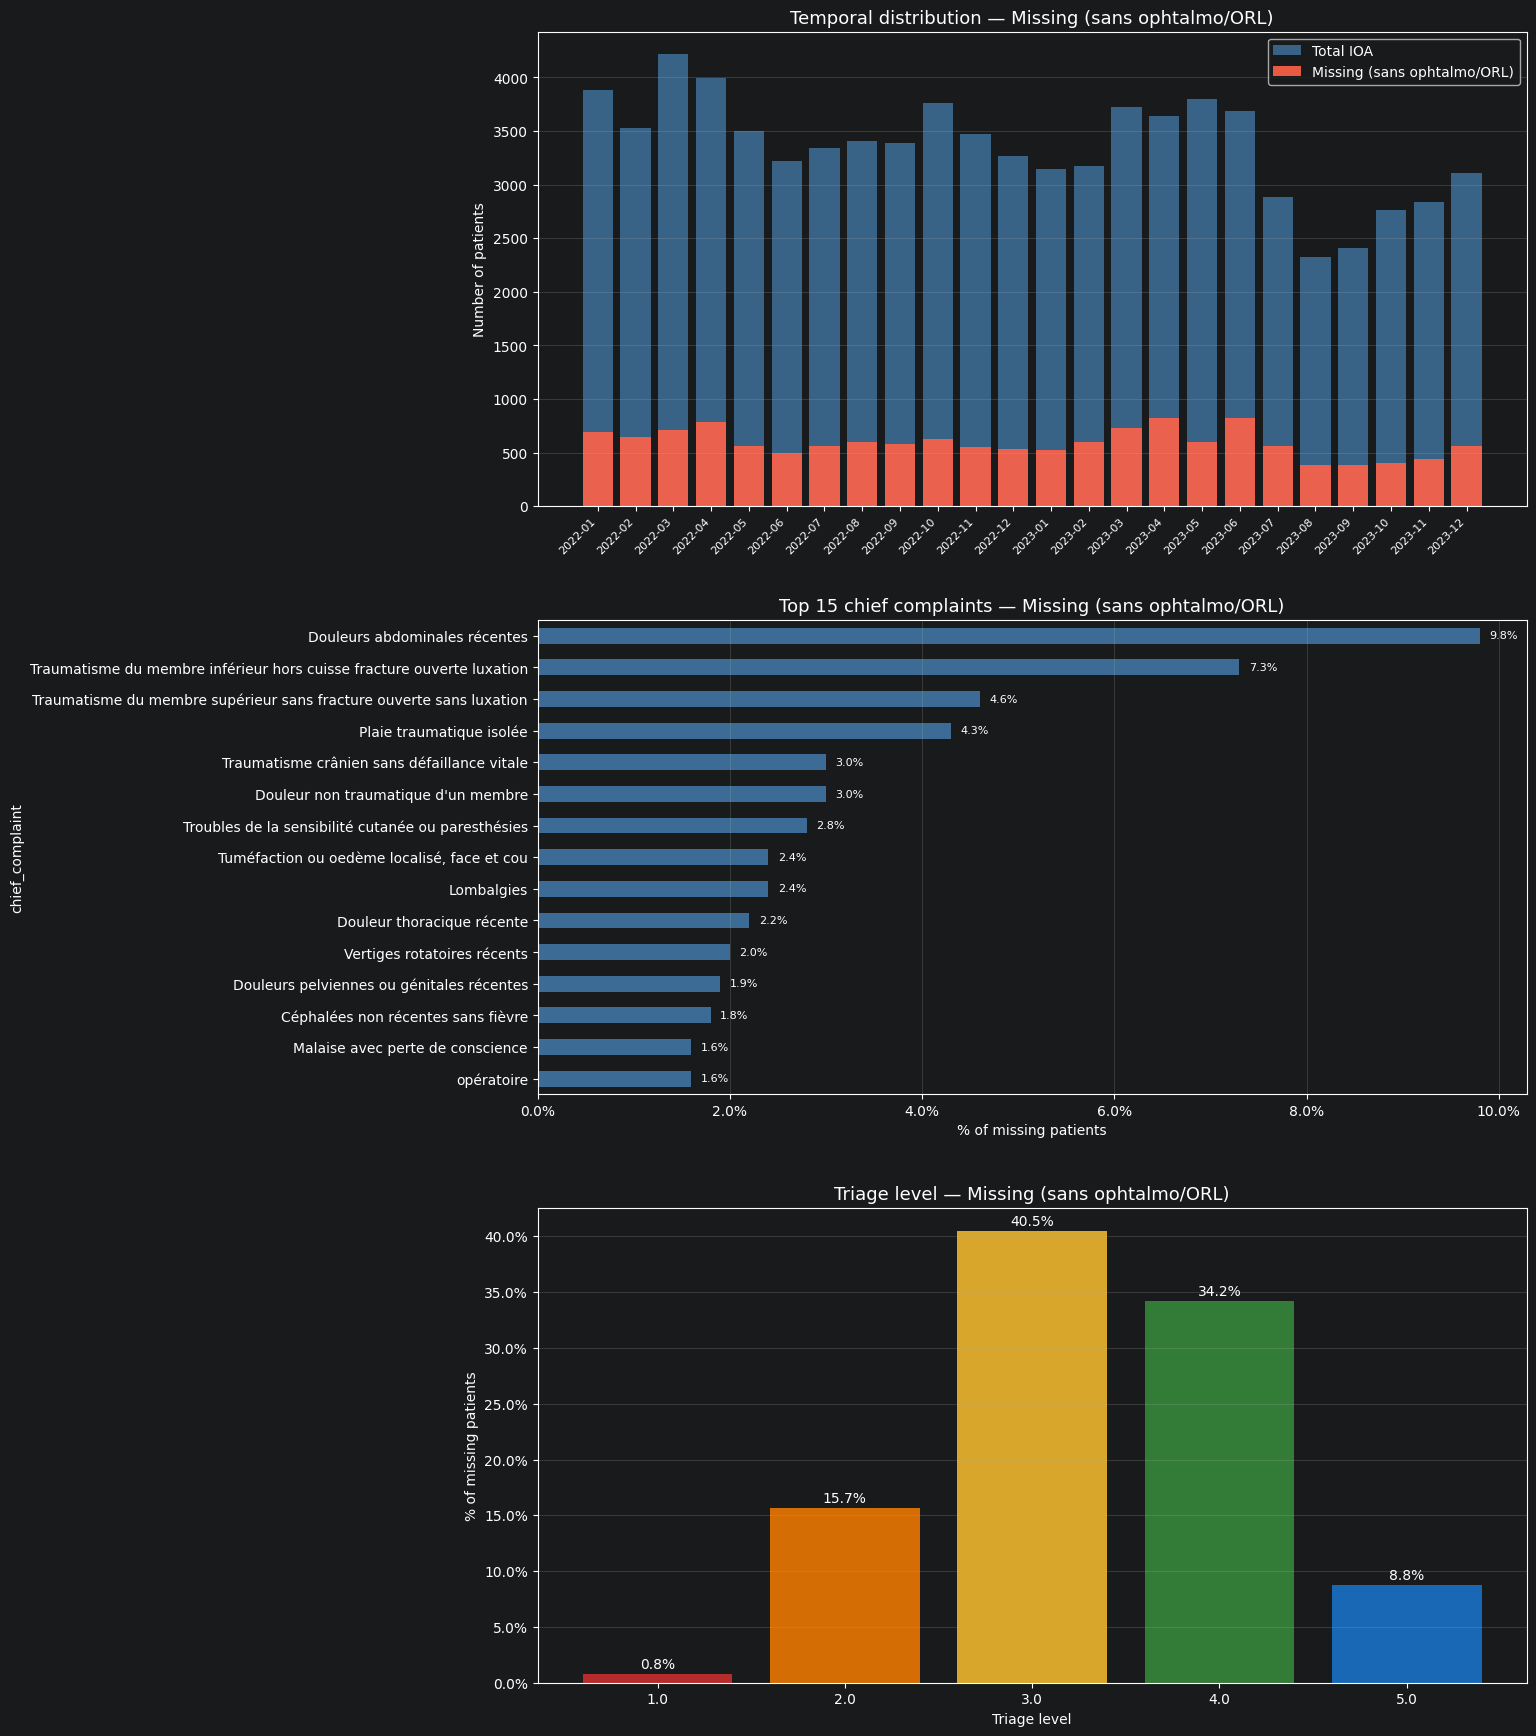

✅ Plot saved: missing_no_oph_orl_final.png


In [157]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# --- Plot 1: Temporal distribution ---
perdus_no_oph_orl['mois'] = pd.to_datetime(
    perdus_no_oph_orl['date_adm_final']
).dt.to_period('M')

volume_global   = df_ioa['mois'].value_counts().sort_index()
volume_restants = perdus_no_oph_orl['mois'].value_counts().sort_index()

months = [str(m) for m in volume_global.index]
x = range(len(months))

axes[0].bar(x, volume_global.values, label='Total IOA', color='steelblue', alpha=0.7)
axes[0].bar(x, volume_restants.reindex(volume_global.index, fill_value=0).values,
            label='Missing (sans ophtalmo/ORL)', color='tomato', alpha=0.9)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(months, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Temporal distribution — Missing (sans ophtalmo/ORL)', fontsize=13)
axes[0].set_ylabel('Number of patients')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Top 15 chief complaints ---
cc_top15 = (
    perdus_no_oph_orl['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .head(15)
    .sort_values()
)
cc_top15.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Top 15 chief complaints — Missing (sans ophtalmo/ORL)', fontsize=13)
axes[1].set_xlabel('% of missing patients')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(cc_top15.values):
    axes[1].text(v + 0.1, i, f'{v}%', va='center', fontsize=8)

# --- Plot 3: Triage level ---
triage_counts = (
    perdus_no_oph_orl['triage']
    .dropna()
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1976d2']
bars = axes[2].bar(
    triage_counts.index.astype(str),
    triage_counts.values,
    color=colors[:len(triage_counts)],
    alpha=0.85
)
axes[2].set_title('Triage level — Missing (sans ophtalmo/ORL)', fontsize=13)
axes[2].set_xlabel('Triage level')
axes[2].set_ylabel('% of missing patients')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, triage_counts.values):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val}%', ha='center', fontsize=10
    )

plt.tight_layout(pad=3.0)
plt.savefig("missing_no_oph_orl_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: missing_no_oph_orl_final.png")

In [158]:
# --- Mots clés dentaires ---
dental_keywords = [
    r"\bdent\b", r"\bdentaire\b", r"\bmolaire\b", r"\bincisive\b",
    r"\bcanine\b", r"\bgencive\b", r"\bgingivite\b",
    "abcès.*dent", "dent.*abcès",
    r"\bpulpite\b", r"\bextraction\b", r"\balvéolite\b", r"\bcarie\b",
    r"\bmâchoire\b", r"\bmandibule\b", r"\bmaxillaire\b",
    r"\bstomatologie\b", r"\borthodont\b"
]

pattern_dental = "|".join(dental_keywords)

mask_dental = perdus_no_ophtalmo['chief_complaint'].str.contains(
    pattern_dental, case=False, na=False, regex=True
)

print(f"Patients avec chief complaint dentaire : {mask_dental.sum():,}")
print("\n=== Chief complaints dentaires ===")
print(perdus_no_ophtalmo[mask_dental]['chief_complaint'].value_counts().to_string())

Patients avec chief complaint dentaire : 165

=== Chief complaints dentaires ===
chief_complaint
Douleur dentaire                    148
Trouble dentaire ou mandibulaire     17


In [169]:
# --- Masque combiné ---
mask_exclus = mask_orl | mask_dental | mask_ophtalmo  # adapte les noms de tes masques

perdus_restants = perdus_no_ophtalmo[~mask_exclus].copy()

print(f"Patients restants après exclusion opht + ORL + dentaire : {len(perdus_restants):,}")
print("\n=== Chief complaints restants ===")
print(perdus_restants['chief_complaint'].value_counts().to_string())

Patients restants après exclusion opht + ORL + dentaire : 14,007

=== Chief complaints restants ===
chief_complaint
Douleurs abdominales récentes                                             1393
Traumatisme du membre inférieur hors cuisse fracture ouverte luxation     1041
Traumatisme du membre supérieur sans fracture ouverte sans luxation        645
Plaie traumatique isolée                                                   613
Douleur non traumatique d'un membre                                        424
Traumatisme crânien sans défaillance vitale                                420
Troubles de la sensibilité cutanée ou paresthésies                         393
Lombalgies                                                                 339
Tuméfaction ou oedème localisé, face et cou                                335
Douleur thoracique récente                                                 305
Vertiges rotatoires récents                                                283
Douleurs pelvie

/tmp/ipykernel_2057442/2773445704.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  perdus_restants = perdus_no_ophtalmo[~mask_exclus].copy()


In [170]:


# --- Préparer les counts (pas normalize) ---
cc_missing_counts = (
    perdus_restants['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts()
)

# Full dataset sans ophtalmo et sans ORL
perdus_restants = (
    df_ioa['chief_complaint'].str.contains(pattern_ophtalmo, case=False, na=False, regex=True) |
    df_ioa['chief_complaint'].str.contains(pattern_orl, case=False, na=False, regex=True)
)
cc_full_counts = (
    df_ioa[~perdus_restants]['chief_complaint']
    .replace(['nan', 'None', '', 'Unknown'], pd.NA)
    .dropna()
    .value_counts()
)

# --- Aligner les deux séries sur les mêmes catégories ---
df_chi2 = pd.DataFrame({
    'missing': cc_missing_counts,
    'full': cc_full_counts
}).fillna(0).astype(int)

# --- Test Chi² ---
chi2, p, dof, expected = chi2_contingency(df_chi2)

print(f"=== CHI² TEST ===")
print(f"Chi²  : {chi2:.2f}")
print(f"p-value : {p:.4f}")
print(f"Degrés de liberté : {dof}")
print()
if p < 0.05:
    print("❌ p < 0.05 → distribution NON random")
    print("   Les missing sont sur/sous-représentés pour certains motifs")
else:
    print("✅ p > 0.05 → distribution compatible avec du random")

# --- Top différences pour comprendre où ça tire ---
df_chi2['missing_pct'] = (df_chi2['missing'] / df_chi2['missing'].sum() * 100).round(1)
df_chi2['full_pct']    = (df_chi2['full']    / df_chi2['full'].sum()    * 100).round(1)
df_chi2['diff']        = (df_chi2['missing_pct'] - df_chi2['full_pct']).round(1)

print("\n=== TOP 10 sur-représentés dans les missing ===")
print(df_chi2.sort_values('diff', ascending=False).head(10)[['missing_pct', 'full_pct', 'diff']].to_string())

print("\n=== TOP 10 sous-représentés dans les missing ===")
print(df_chi2.sort_values('diff', ascending=True).head(10)[['missing_pct', 'full_pct', 'diff']].to_string())

=== CHI² TEST ===
Chi²  : 1048.62
p-value : 0.0000
Degrés de liberté : 169

❌ p < 0.05 → distribution NON random
   Les missing sont sur/sous-représentés pour certains motifs

=== TOP 10 sur-représentés dans les missing ===
                                                               missing_pct  full_pct  diff
chief_complaint                                                                           
Plaie traumatique isolée                                               4.4       3.2   1.2
Tuméfaction ou oedème localisé, face et cou                            2.4       1.3   1.1
opératoire                                                             1.7       1.0   0.7
Problème avec dispositif médical/sonde/stomie                          1.4       0.7   0.7
Corps étranger avalé sans blocage des aliments                         0.9       0.4   0.5
Symptôme non classé ailleurs sans critère de gravité                   1.1       0.6   0.5
Demande d'examen complémentaire sans symptôme   

In [160]:
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, expected = chi2_contingency(df_chi2[['missing', 'full']])

# --- Cramér's V ---
n = df_chi2[['missing', 'full']].values.sum()
k = min(df_chi2[['missing', 'full']].shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print(f"Chi²       : {chi2:.2f}")
print(f"p-value    : {p:.4f}")
print(f"Cramér's V : {cramers_v:.4f}")
print()
print("Interprétation Cramér's V :")
print("  < 0.10    → effet négligeable → probablement random")
print("  0.10-0.20 → effet faible")
print("  0.20-0.30 → effet modéré")
print("  > 0.30    → effet fort → biais réel")

Chi²       : 1059.43
p-value    : 0.0000
Cramér's V : 0.1138

Interprétation Cramér's V :
  < 0.10    → effet négligeable → probablement random
  0.10-0.20 → effet faible
  0.20-0.30 → effet modéré
  > 0.30    → effet fort → biais réel




"Les dossiers médicaux manquants présentent une distribution des motifs de recours globalement similaire à celle de la population totale (Cramér's V = 0.13), suggérant un biais de sélection faible. La significativité statistique du test du Chi² (p < 0.001) est à interpréter avec prudence compte tenu de la taille de l'échantillon."

In [161]:

# ============================================================
# 1. LOADING AND STRICT CLEANING
# ============================================================
def get_clean_nda_set(df, col_name):
    return set(
        df[col_name]
        .dropna()
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.strip()
        .str.lstrip('0')
    )



# Extract cleaned NDA sets
set_admin = get_clean_nda_set(df_admin, 'nda')
set_ioa = get_clean_nda_set(df_ioa, 'nda')
set_med = get_clean_nda_set(df_med, 'nda')

# ============================================================
# 2. SET INTERSECTIONS (3-WAY CONSISTENCY CHECK)
# ============================================================
all_three = set_admin.intersection(set_ioa).intersection(set_med)
admin_and_ioa_no_med = set_admin.intersection(set_ioa).difference(set_med)
admin_only = set_admin.difference(set_ioa).difference(set_med)
med_only = set_med.difference(set_admin).difference(set_ioa)

# ============================================================
# 3. TRIPARTITE CONSISTENCY REPORT
# ============================================================
print("🔍 DATASET CONSISTENCY AUDIT (3 SOURCES)")
print("-" * 50)
print(f"📁 ADMIN source (total population): {len(set_admin)}")
print(f"📁 IOA source (vital signs):       {len(set_ioa)}")
print(f"📁 MEDICAL source (diagnoses):     {len(set_med)}")
print("-" * 50)

print(f"✅ COMPLETE RECORDS (3/3):          {len(all_three)}")
print(f"⚠️ ADMIN + IOA but NO MEDICAL:      {len(admin_and_ioa_no_med)}")
print(f"🚫 ADMIN only (total loss):         {len(admin_only)}")
print(f"❓ MEDICAL orphan (no admin):       {len(med_only)}")
print("-" * 50)

# ============================================================
# 4. COMPLETENESS RATE
# ============================================================
if len(set_admin) > 0:
    completeness_rate = (len(all_three) / len(set_admin)) * 100
    print(f"📊 Usable records for clustering: {completeness_rate:.1f}%")


🔍 DATASET CONSISTENCY AUDIT (3 SOURCES)
--------------------------------------------------
📁 ADMIN source (total population): 90525
📁 IOA source (vital signs):       80495
📁 MEDICAL source (diagnoses):     60289
--------------------------------------------------
✅ COMPLETE RECORDS (3/3):          57389
⚠️ ADMIN + IOA but NO MEDICAL:      23078
🚫 ADMIN only (total loss):         7162
❓ MEDICAL orphan (no admin):       2
--------------------------------------------------
📊 Usable records for clustering: 63.4%


In [162]:
# ============================================================
# 1. UNIFIED NDA CLEANING FUNCTION
# ============================================================
def clean_nda(series):
    """Clean NDA identifiers: remove .0, trim spaces, remove leading zeros."""
    return (
        series.dropna()
              .astype(str)
              .str.replace(r'\.0$', '', regex=True)
              .str.strip()
              .str.lstrip('0')
    )

# ============================================================
# 2. LOAD ALL SOURCES
# ============================================================
print("Loading datasets...")



# ============================================================
# 3. CLEAN NDA AND BUILD SETS
# ============================================================

d_admin = pd.read_csv("Datasets/df_admin_2022_2023.csv", dtype={'nda': str})
d_ioa   = pd.read_csv("Datasets/df_ioa_2022_2023.csv",   dtype={'nda': str})
d_vits  = pd.read_csv("Datasets/df_param_vit_2022_2023.csv", dtype={'nda': str})
d_med   = pd.read_csv("Datasets/df_med_2022_2023.csv",   dtype={'nda': str})

sources = {
    "ADMIN": clean_nda(d_admin['nda']),
    "IOA": clean_nda(d_ioa['nda']),
    "VITALS": clean_nda(d_vits['nda']),
    "MEDICAL": clean_nda(d_med['nda'])
}

sets = {name: set(values) for name, values in sources.items()}

# ============================================================
# 4. GLOBAL COMPLETENESS (4-WAY INTERSECTION)
# ============================================================
all_common = (
    sets["ADMIN"]
    .intersection(sets["IOA"])
    .intersection(sets["VITALS"])
    .intersection(sets["MEDICAL"])
)

print("\n" + "=" * 70)
print("🔎 GLOBAL NDA COMPLETENESS AUDIT (4 SOURCES)")
print("=" * 70)

for name, s in sets.items():
    print(f"📁 {name:<15} : {len(s):>6} unique patients")

print("-" * 70)
print(f"✅ COMPLETE PATIENTS (4/4) : {len(all_common)}")
print(f"📉 COMPLETENESS RATE       : {(len(all_common) / len(sets['ADMIN']) * 100):.1f}%")
print("-" * 70)

# ============================================================
# 5. DETAILED MISSINGNESS ANALYSIS (PAIRWISE GAPS)
# ============================================================
ioa_no_vits = len(sets["IOA"] - sets["VITALS"])
ioa_no_med = len(sets["IOA"] - sets["MEDICAL"])
med_no_ioa = len(sets["MEDICAL"] - sets["IOA"])
admin_no_med = len(sets["ADMIN"] - sets["MEDICAL"])
admin_no_ioa = len(sets["ADMIN"] - sets["IOA"])
vits_no_admin = len(sets["VITALS"] - sets["ADMIN"])

print("\n" + "=" * 70)
print("🩺 DETAILED DISCORDANCE ANALYSIS (ORPHAN RECORDS)")
print("=" * 70)

print(f"🔹 IOA but NO VITALS                 = {ioa_no_vits}")
print(f"🔹 IOA but NO MEDICAL                = {ioa_no_med}")
print(f"🔹 MEDICAL but NO IOA                = {med_no_ioa}")
print(f"🔹 ADMIN but NO MEDICAL              = {admin_no_med}")
print(f"🔹 ADMIN but NO IOA                  = {admin_no_ioa}")
print(f"🔹 VITALS but NO ADMIN               = {vits_no_admin}")

print("-" * 70)
print(f"✅ FULLY USABLE RECORDS (4/4)        : {len(all_common)}")
print("=" * 70)

# ============================================================
# 6. COLUMN INVENTORY FOR ALL FILES
# ============================================================
files = {
    "ADMIN": "Datasets/df_admin_2022_2023.csv",
    "MEDICAL": "Datasets/df_med_2022_2023.csv",
    "IOA/VITALS": "Datasets/df_ioafile_paramvit_clean.csv"
}

print("\n📋 COLUMN INVENTORY BY SOURCE")
print("=" * 50)

all_columns = {}

for name, path in files.items():
    try:
        df_temp = pd.read_csv(path, nrows=1)
        cols = df_temp.columns.tolist()
        all_columns[name] = cols

        print(f"\n📂 Source: {name}")
        print(f"Total columns: {len(cols)}")
        print(f"List: {', '.join(cols)}")
        print("-" * 50)

    except Exception as e:
        print(f"❌ Could not read {name}: {e}")

# ============================================================
# 7. COMMON COLUMNS ACROSS ALL FILES
# ============================================================
if len(all_columns) > 1:
    common_cols = set.intersection(*[set(cols) for cols in all_columns.values()])
    print("\n🔑 Columns common to ALL files:")
    print(common_cols if common_cols else "None (check join keys!)")


Loading datasets...

🔎 GLOBAL NDA COMPLETENESS AUDIT (4 SOURCES)
📁 ADMIN           :  90525 unique patients
📁 IOA             :  81396 unique patients
📁 VITALS          :  59727 unique patients
📁 MEDICAL         :  60289 unique patients
----------------------------------------------------------------------
✅ COMPLETE PATIENTS (4/4) : 44679
📉 COMPLETENESS RATE       : 49.4%
----------------------------------------------------------------------

🩺 DETAILED DISCORDANCE ANALYSIS (ORPHAN RECORDS)
🔹 IOA but NO VITALS                 = 23462
🔹 IOA but NO MEDICAL                = 23274
🔹 MEDICAL but NO IOA                = 2167
🔹 ADMIN but NO MEDICAL              = 30240
🔹 ADMIN but NO IOA                  = 9157
🔹 VITALS but NO ADMIN               = 26
----------------------------------------------------------------------
✅ FULLY USABLE RECORDS (4/4)        : 44679

📋 COLUMN INVENTORY BY SOURCE

📂 Source: ADMIN
Total columns: 9
List: uam_service, nda, date_naissance, date_entree_urg, date_sor

EKG MINING

In [163]:
# from rapidfuzz import fuzz
#
# # ============================================================
# # 0. HELPER FUNCTIONS
# # ============================================================
# def get_context_snippet(row, window=80):
#     """Extracts a text snippet around the detected keyword."""
#     try:
#         sources_list = str(row['ekg_source_column']).split(' & ')
#         primary_col = sources_list[0]
#         if primary_col == "not_found" or primary_col not in row:
#             return ""
#         text_str = str(row[primary_col])
#         keyword = str(row['ekg_keyword_found'])
#         if not keyword or keyword == 'nan':
#             return "Keyword missing"
#         match = re.search(re.escape(keyword), text_str, re.IGNORECASE)
#         if match:
#             start = max(0, match.start() - window)
#             end = min(len(text_str), match.end() + window)
#             return f"...{text_str[start:end]}..."
#         return "Context not found"
#     except:
#         return "Error in snippet"
#
#
# # ============================================================
# # 1. PATTERNS
# # ============================================================
#
#
# # Regex pattern pour la DETECTION (str.contains)
# ekg_pattern = r"""(?ix)
#     \becg\b                      # ECG exact
#   | \begc\b                      # EGC (inversion)
#   | \begg\b                      # EGG (faute)
#   | \becc\b                      # ECC (faute)
#   | \bekg\b                      # EKG variant
#   | e\.c\.g                      # E.C.G
#   | el{1,2}ec?tro                # electro, ellectro, elecro...
#     (?!\s*enc)                   # excludes electroencephalo
#     (?!\s*my)                    # excludes electromyo
#     (?!\s*lyt)                   # excludes electrolyte
#     (?!\s*od)                    # excludes electrode
#     (?:\s*[-:.]?\s*car?\w*)?     # optional: cardio, cardiogramme...
#   | electrocar\w*                # electrocardiogramme variants
# """
#
# # Pattern simplifié pour l'EXTRACTION du mot-clé (str.extract)
# ekg_extract_pattern = r'(ecg|egc|egg|ecc|ekg|e\.c\.g|el{1,2}ec?tro\w*|electrocar\w*)'
#
# # Fuzzy references
# EKG_REFS   = ["electrocardiogramme", "electrocardiographie", "ecg", "ekg", "electro"]
# EXCLUSIONS = ["electroencephalogramme", "electromyogramme",
#               "electrolyte", "electrode", "electrolyse"]
#
# def fuzzy_detect_ekg(text, threshold=80):
#     """Word-by-word fuzzy matching — returns (bool, keyword_found)."""
#     words = str(text).lower().split()
#     for word in words:
#         if len(word) < 3:
#             continue
#         # Check exclusions first
#         for excl in EXCLUSIONS:
#             if fuzz.ratio(word, excl) > 85:
#                 return False, None
#         # Check EKG refs
#         for ref in EKG_REFS:
#             if fuzz.ratio(word, ref) > threshold:
#                 return True, word
#     return False, None
#
#
# # ============================================================
# # 2. PREPARE COLUMNS
# # ============================================================
# cols_to_scan = ['clinical_exam', 'evolution', 'conclusion', 'additional_tests', 'evolution_ioa']
# print(f"🔍 Scanning {len(df_med):,} records...")
#
# c_exam  = df_med['clinical_exam'].fillna('').astype(str).str.lower()
# c_evol  = df_med['evolution'].fillna('').astype(str).str.lower()
# c_conc  = df_med['conclusion'].fillna('').astype(str).str.lower()
# c_tests = df_med['additional_tests'].fillna('').astype(str).str.lower()
# c_ioa   = (df_ioa['evolution_ioa'].fillna('').astype(str).str.lower()
#            if 'evolution_ioa' in df_ioa.columns
#            else pd.Series([''] * len(df_ioa), index=df_ioa.index))
#
#
# # ============================================================
# # 3. STEP 1 — REGEX DETECTION (fast, all patients)
# # ============================================================
# print("⚡ Step 1: Regex detection...")
#
# f_exam  = c_exam.str.contains(ekg_pattern,  regex=True, na=False)
# f_evol  = c_evol.str.contains(ekg_pattern,  regex=True, na=False)
# f_conc  = c_conc.str.contains(ekg_pattern,  regex=True, na=False)
# f_tests = c_tests.str.contains(ekg_pattern, regex=True, na=False)
# f_ioa   = c_ioa.str.contains(ekg_pattern,   regex=True, na=False)
#
# regex_detected = f_exam | f_evol | f_conc | f_tests | f_ioa
# print(f"  → Regex detected : {regex_detected.sum():,} patients")
#
#
# # ============================================================
# # 4. STEP 2 — FUZZY DETECTION (only on regex negatives)
# # ============================================================
# print("🔎 Step 2: Fuzzy detection on non-detected patients...")
#
# neg_idx = df_med.index[~regex_detected]
# print(f"  → Fuzzy scanning {len(neg_idx):,} patients...")
#
# fuzzy_flags   = pd.Series(False, index=df_med.index)
# fuzzy_keywords = pd.Series('', index=df_med.index)
#
# for idx in neg_idx:
#     all_text = " ".join([
#         c_exam[idx], c_evol[idx], c_conc[idx],
#         c_tests[idx], c_ioa[idx]
#     ])
#     found, keyword = fuzzy_detect_ekg(all_text)
#     if found:
#         fuzzy_flags[idx]    = True
#         fuzzy_keywords[idx] = keyword if keyword else ''
#
# print(f"  → Fuzzy detected : {fuzzy_flags.sum():,} additional patients")
#
#
# # ============================================================
# # 5. COMBINE RESULTS
# # ============================================================
# df_med['had_ekg']           = (regex_detected | fuzzy_flags).astype(int)
# df_med['ekg_detected_by']   = np.where(
#     regex_detected, 'regex',
#     np.where(fuzzy_flags, 'fuzzy', 'none')
# )
#
# # Source columns
# def identify_sources(row_idx):
#     srcs = []
#     if f_exam[row_idx]:  srcs.append('clinical_exam')
#     if f_evol[row_idx]:  srcs.append('evolution')
#     if f_conc[row_idx]:  srcs.append('conclusion')
#     if f_tests[row_idx]: srcs.append('additional_tests')
#     if f_ioa[row_idx]:   srcs.append('evolution_ioa')
#     if fuzzy_flags[row_idx] and not srcs:
#         srcs.append('fuzzy_match')
#     return " & ".join(srcs) if srcs else "not_found"
#
# df_med['ekg_source_column'] = [identify_sources(i) for i in df_med.index]
#
# # Keyword found
# all_text_series = c_exam + " " + c_evol + " " + c_conc + " " + c_tests + " " + c_ioa
# # APRÈS
# regex_keywords = all_text_series.str.extract(
#     ekg_extract_pattern,
#     flags=re.IGNORECASE,
#     expand=False
# )
# df_med['ekg_keyword_found'] = np.where(
#     regex_detected, regex_keywords,
#     np.where(fuzzy_flags, fuzzy_keywords, '')
# )
#
#
# # ============================================================
# # 6. STATS
# # ============================================================
# n_cols = (f_exam.astype(int) + f_evol.astype(int) +
#           f_conc.astype(int) + f_tests.astype(int) +
#           f_ioa.astype(int))
#
# print("\n" + "="*50)
# print("📊 EKG DETECTED PER COLUMN (regex)")
# print("="*50)
# print(f"  clinical_exam    : {f_exam.sum():,}")
# print(f"  evolution        : {f_evol.sum():,}")
# print(f"  conclusion       : {f_conc.sum():,}")
# print(f"  additional_tests : {f_tests.sum():,}")
# print(f"  evolution_ioa    : {f_ioa.sum():,}")
#
# print("\n" + "="*50)
# print("📊 OVERLAP BETWEEN COLUMNS")
# print("="*50)
# print(f"  Detected in 1 column only : {(n_cols == 1).sum():,}")
# print(f"  Detected in 2 columns     : {(n_cols == 2).sum():,}")
# print(f"  Detected in 3+ columns    : {(n_cols >= 3).sum():,}")
#
# print("\n" + "="*50)
# print("📊 DETECTION METHOD SUMMARY")
# print("="*50)
# print(f"  Regex only   : {(regex_detected & ~fuzzy_flags).sum():,}")
# print(f"  Fuzzy only   : {fuzzy_flags.sum():,}")
# print(f"  TOTAL had_ekg: {df_med['had_ekg'].sum():,}")
#
# print("\n" + "="*50)
# print("📊 MOST FREQUENT COLUMN COMBINATIONS")
# print("="*50)
# df_overlap = pd.DataFrame({
#     'clinical_exam':    f_exam.values,
#     'evolution':        f_evol.values,
#     'conclusion':       f_conc.values,
#     'additional_tests': f_tests.values,
#     'evolution_ioa':    f_ioa.values
# }, index=df_med.index)
# combo_counts = (
#     df_overlap[df_overlap.any(axis=1)]
#     .astype(int)
#     .apply(lambda row: ' & '.join([col for col, val in row.items() if val]), axis=1)
#     .value_counts()
# )
# print(combo_counts.head(10).to_string())
#
# # IOA only
# med_found = f_exam | f_evol | f_conc | f_tests
# ioa_only_count = (f_ioa & ~med_found).sum()
# print(f"\n  IOA-only detections : {ioa_only_count:,}")
#
#
# # ============================================================
# # 7. AUDIT EXPORT
# # ============================================================
# df_ekg_all = df_med[df_med['had_ekg'] == 1].copy()
#
# if not df_ekg_all.empty:
#     df_electrocar   = df_ekg_all[df_ekg_all['ekg_keyword_found'].str.contains('electrocar', na=False)]
#     df_fuzzy_sample = df_ekg_all[df_ekg_all['ekg_detected_by'] == 'fuzzy']
#     df_others       = df_ekg_all[
#         ~df_ekg_all['ekg_keyword_found'].str.contains('electrocar', na=False) &
#         (df_ekg_all['ekg_detected_by'] != 'fuzzy')
#     ]
#
#     sample_size    = min(300, len(df_others))
#     df_audit = pd.concat([
#         df_electrocar,
#         df_fuzzy_sample,
#         df_others.sample(n=sample_size, random_state=42)
#     ]).drop_duplicates(subset='nda').copy()
#
#     print("\n🪄 Generating context snippets...")
#     df_audit['ekg_snippet'] = df_audit.apply(get_context_snippet, axis=1)
#
#     export_cols = ['nda', 'diag', 'ekg_source_column',
#                    'ekg_keyword_found', 'ekg_detected_by', 'ekg_snippet']
#     df_audit[export_cols].to_csv(
#         "audit_ekg_final_with_counts.csv",
#         index=False, sep=';', encoding='utf-8-sig'
#     )
#     print(f"✅ Audit file created: audit_ekg_final_with_counts.csv")
# else:
#     print("⚠️ No EKG detected.")

### ACTUAL MERGING OF THE 3 FILES (IOA/VITALS + ADMIN + MEDICAL) ###


In [164]:
# import pandas as pd
# import numpy as np
#
# # ============================================================
# # 1. LOAD SOURCES
# # ============================================================
# print("📥 Loading datasets...")
#
#
#
# # ============================================================
# # 2. NDA CLEANING (STRICT MATCHING)
# # ============================================================
# for df in [df_admin, df_ioa, df_med]:
#     df['nda'] = (
#         df['nda'].astype(str)
#                  .str.replace(r'\.0$', '', regex=True)
#                  .str.strip()
#                  .str.lstrip('0')
#     )
#
# # ============================================================
# # 3. COLUMN SELECTION AND RENAMING
# # ============================================================
#
# # Admin subset
# df_admin_sub = df_admin[['nda', 'uam_service', 'date_entree', 'date_sortie', 'date_naissance', 'mode_sortie', 'decision_urgence']].rename(
#     columns={'date_entree': 'date_entree_adm_file'}
# )
#
# # Medical subset
# cols_med = [
#     'nda', 'sex', 'age', 'date_adm_med', 'diag', 'anam_ed', 'atcd_med', 'had_ekg', 'additional_tests',
#     'rx_home', 'clinical_exam', 'rx_ed', 'evolution', 'conclusion', 'disposition_med', 'source_file'
# ]
#
# df_med_sub = df_med[cols_med].rename(
#     columns={'date_adm_med': 'date_adm_med_file', 'anam_urg': 'anam_med'}
# )
#
# # ============================================================
# # 4. MERGING PIPELINE (INNER MERGE = COMPLETE RECORDS ONLY)
# # ============================================================
# print("⚙️ Merging datasets...")
#
# # Step A: Admin + IOA
# inter_admin_ioa = pd.merge(df_admin_sub, df_ioa, on='nda', how='inner')
# lost_ioa = len(df_admin_sub) - len(inter_admin_ioa)
#
# # Step B: Add Medical
# df_final = pd.merge(inter_admin_ioa, df_med_sub, on='nda', how='inner')
# lost_med = len(inter_admin_ioa) - len(df_final)
#
# # # ============================================================
# # # 4.5 CONSOLIDATE ECG FLAGS (ekg_flag + has_ekg)
# # # ============================================================
# # print("⚡ Consolidating ECG flags...")
# #
# # # check that variables present and numerical
# # for col in ['ekg_flag', 'has_ekg']:
# #     if col in df_final.columns:
# #         df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0).astype(int)
# #     else:
# #         df_final[col] = 0 # security if missing column
# #
# # # creation 'had_ekg' (Logical OR)
# # df_final['had_ekg'] = df_final[['ekg_flag', 'has_ekg']].max(axis=1)
# #
# # # remove old columns
# # df_final.drop(columns=['ekg_flag', 'has_ekg'], inplace=True)
# #
# # print(f"✅ ECG flags unified. Total EKG: {df_final['had_ekg'].sum()}")
#
# # ============================================================
# # 5. MERGE REPORT
# # ============================================================
# print("\n" + "="*60)
# print("📊 MERGE REPORT (ONLY COMPLETE RECORDS RETAINED)")
# print("="*60)
# print(f"✅ Final number of retained patients : {len(df_final)}")
# print("-" * 60)
# print(f"❌ Removed due to missing IOA/Vitals : {lost_ioa}")
# print(f"❌ Removed due to missing Medical    : {lost_med}")
# print(f"📉 Total removed                     : {lost_ioa + lost_med}")
# print("=" * 60)
#
# # ============================================================
# # 6. DATE CONSISTENCY CHECK
# # ============================================================
# date_cols = ["date_entree_adm_file", "date_adm_final", "date_adm_med_file"]
#
# for col in date_cols:
#     df_final[col] = pd.to_datetime(df_final[col], errors='coerce')
#
# check_admin = (df_final["date_entree_adm_file"] == df_final["date_adm_final"]).all()
# check_med = (df_final["date_entree_adm_file"] == df_final["date_adm_med_file"]).all()
#
# print("\n🧐 DATE CONSISTENCY CHECK")
# print("-" * 40)
# print(f"Admin vs Final   : {'✅ Identical' if check_admin else '❌ Different'}")
# print(f"Admin vs Medical : {'✅ Identical' if check_med else '❌ Different'}")
#
# if not check_med:
#     avg_diff = (df_final["date_adm_med_file"] - df_final["date_entree_adm_file"]).dt.total_seconds().mean() / 60
#     print(f"\n💡 Average difference (Admin vs Medical): {avg_diff:.1f} minutes.")
#
# # ============================================================
# # 7. UNIFY ADMISSION DATE
# # ============================================================
# df_final.columns = df_final.columns.str.strip()
# df_final['datetime_admission'] = df_final.pop('date_adm_final')
# df_final.drop(columns=['date_entree_adm_file', 'date_adm_med_file'], inplace=True, errors='ignore')
#
# print("\n✅ Admission date unified into 'datetime_admission'.")
#
# # ============================================================
# # 8. COLUMN REORDERING
# # ============================================================
# desired_start = [
#     'nda', 'sex', 'date_naissance', 'age', 'uam_service',
#     'hospital', 'origines_donneees', 'transport', 'datetime_admission'
# ]
#
# existing_start = [c for c in desired_start if c in df_final.columns]
# other_cols = [c for c in df_final.columns if c not in existing_start]
#
# df_final = df_final[existing_start + other_cols]
#
# print("\n✅ Columns successfully reordered.")
# print(f"First 9 columns: {df_final.columns[:9].tolist()}")
#
# # ============================================================
# # 9. AGE VALIDATION (ADMIN vs CALCULATED)
# # ============================================================
# df_final['date_naissance'] = pd.to_datetime(df_final['date_naissance'], errors='coerce')
# df_final['datetime_admission'] = pd.to_datetime(df_final['datetime_admission'], errors='coerce')
#
# age_calc = (df_final['datetime_admission'] - df_final['date_naissance']).dt.days / 365.25
# df_final['age_calcule'] = age_calc.apply(lambda x: int(x) if pd.notnull(x) else None)
#
# if 'age' in df_final.columns:
#     df_final['age'] = pd.to_numeric(df_final['age'], errors='coerce')
#     diff_age = df_final[df_final['age'] != df_final['age_calcule']]
#
#     print("\n📊 AGE CONSISTENCY ANALYSIS")
#     print(f"Matching ages     : {len(df_final) - len(diff_age)}")
#     print(f"Age discrepancies : {len(diff_age)}")
#
#     if not diff_age.empty:
#         print("\nExample discrepancies:")
#         print(diff_age[['nda', 'date_naissance', 'datetime_admission', 'age', 'age_calcule']].head())
# else:
#     df_final['age'] = df_final['age_calcule']
#     print("ℹ️ Age column created from birth date.")
#
# df_final.drop(columns=['age_calcule'], inplace=True)
#
# # ============================================================
# # 10. AGE ERROR ANALYSIS (> 1 YEAR)
# # ============================================================
# age_theo = (df_final['datetime_admission'] - df_final['date_naissance']).dt.days / 365.25
# df_final['age'] = pd.to_numeric(df_final['age'], errors='coerce')
# df_final['ecart_age'] = df_final['age'] - age_theo
#
# print("\n📊 GLOBAL AGE ERROR STATS")
# print(df_final['ecart_age'].describe())
# print("-" * 40)
#
# mask_err = df_final['ecart_age'].abs() > 1
# df_err = df_final[mask_err]
#
# print(f"🧐 AGE DISCREPANCIES > 1 YEAR: {len(df_err)} ({len(df_err)/len(df_final)*100:.2f}%)")
#
# if not df_err.empty:
#     print("\n📈 Error-only stats:")
#     print

In [165]:
print(df_admin.columns.tolist())

['uam_service', 'nda', 'date_naissance', 'date_entree_urg', 'date_sortie_urg', 'date_sortie_urg_completee', 'decision_urgence', 'date_sortie_chu', 'mode_sortie_chu']


In [166]:
import pandas as pd
import numpy as np
import re
from rapidfuzz import fuzz

# ============================================================
# 1. NDA CLEANING
# ============================================================
def clean_nda(series):
    return (series.astype(str)
                  .str.replace(r'\.0$', '', regex=True)
                  .str.strip()
                  .str.lstrip('0'))

for df in [df_admin, df_ioa, df_med]:
    df['nda'] = clean_nda(df['nda'])

# ============================================================
# 2. COLUMN SELECTION
# ============================================================
df_admin_sub = df_admin[[
    'nda', 'uam_service', 'date_entree_urg', 'date_sortie_urg', 'date_sortie_chu', 'date_sortie_urg_completee',
    'date_naissance', 'mode_sortie_chu', 'decision_urgence'
]].rename(columns={'date_entree_urg': 'date_entree_adm_file'})

cols_med = [
    'nda', 'sex', 'age', 'date_adm_med', 'diag',
    'anam_ed', 'atcd_med', 'additional_tests',
    'rx_home', 'clinical_exam', 'rx_ed', 'evolution',
    'conclusion', 'disposition_med', 'source_file'
]
df_med_sub = df_med[[c for c in cols_med if c in df_med.columns]].rename(
    columns={'date_adm_med': 'date_adm_med_file'}
)

# ============================================================
# 3. MERGE PIPELINE
# ============================================================
print("⚙️ Merging datasets...")

inter_admin_ioa = pd.merge(df_admin_sub, df_ioa, on='nda', how='inner')
lost_ioa = len(df_admin_sub) - len(inter_admin_ioa)

df_final = pd.merge(inter_admin_ioa, df_med_sub, on='nda', how='inner')
lost_med = len(inter_admin_ioa) - len(df_final)

print(f"\n{'='*60}")
print(f"📊 MERGE REPORT")
print(f"{'='*60}")
print(f"✅ Patients retained          : {len(df_final):,}")
print(f"❌ Lost (missing IOA/Vitals)  : {lost_ioa:,}")
print(f"❌ Lost (missing Medical)     : {lost_med:,}")
print(f"📉 Total removed              : {lost_ioa + lost_med:,}")
print(f"{'='*60}")

# ============================================================
# 4. EKG PATTERNS & FUNCTIONS
# ============================================================
ekg_pattern = r"""(?ix)
    \becg\b                      # ECG exact
  | \begc\b                      # EGC (inversion)
  | \begg\b                      # EGG (faute)
  | \becc\b                      # ECC (faute)
  | \bekg\b                      # EKG variant
  | e\.c\.g                      # E.C.G
  | el{1,2}ec?tro                # electro, ellectro, elecro...
    (?!\s*enc)                   # excludes electroencephalo
    (?!\s*my)                    # excludes electromyo
    (?!\s*lyt)                   # excludes electrolyte
    (?!\s*od)                    # excludes electrode
    (?:\s*[-:.]?\s*car?\w*)?     # optional: cardio, cardiogramme...
  | electrocar\w*                # electrocardiogramme variants
"""

ekg_extract_pattern = r'(ecg|egc|egg|ecc|ekg|e\.c\.g|el{1,2}ec?tro\w*|electrocar\w*)'

EKG_REFS   = ["electrocardiogramme", "electrocardiographie", "ecg", "ekg", "electro"]
EXCLUSIONS = ["electroencephalogramme", "electromyogramme",
              "electrolyte", "electrode", "electrolyse"]

def fuzzy_detect_ekg(text, threshold=80):
    words = str(text).lower().split()
    for word in words:
        if len(word) < 3:
            continue
        for excl in EXCLUSIONS:
            if fuzz.ratio(word, excl) > 85:
                return False, None
        for ref in EKG_REFS:
            if fuzz.ratio(word, ref) > threshold:
                return True, word
    return False, None

def get_context_snippet(row, window=80):
    try:
        sources_list = str(row['ekg_source_column']).split(' & ')
        primary_col = sources_list[0]
        if primary_col == "not_found" or primary_col not in row.index:
            return ""
        text_str = str(row[primary_col])
        keyword = str(row['ekg_keyword_found'])
        if not keyword or keyword == 'nan':
            return "Keyword missing"
        match = re.search(re.escape(keyword), text_str, re.IGNORECASE)
        if match:
            start = max(0, match.start() - window)
            end = min(len(text_str), match.end() + window)
            return f"...{text_str[start:end]}..."
        return "Context not found"
    except:
        return "Error in snippet"

# ============================================================
# 5. EKG MINING ON df_final
# ============================================================
print(f"\n🔍 EKG mining on {len(df_final):,} merged records...")

c_exam  = df_final['clinical_exam'].fillna('').astype(str).str.lower()
c_evol  = df_final['evolution'].fillna('').astype(str).str.lower()
c_conc  = df_final['conclusion'].fillna('').astype(str).str.lower()
c_tests = df_final['additional_tests'].fillna('').astype(str).str.lower()
c_ioa   = df_final['evolution_ioa'].fillna('').astype(str).str.lower() \
          if 'evolution_ioa' in df_final.columns \
          else pd.Series([''] * len(df_final), index=df_final.index)

# Step 1: Regex
print("⚡ Step 1: Regex detection...")
f_exam  = c_exam.str.contains(ekg_pattern,  regex=True, na=False)
f_evol  = c_evol.str.contains(ekg_pattern,  regex=True, na=False)
f_conc  = c_conc.str.contains(ekg_pattern,  regex=True, na=False)
f_tests = c_tests.str.contains(ekg_pattern, regex=True, na=False)
f_ioa   = c_ioa.str.contains(ekg_pattern,   regex=True, na=False)

regex_detected = f_exam | f_evol | f_conc | f_tests | f_ioa
print(f"  → Regex detected : {regex_detected.sum():,} patients")

# Step 2: Fuzzy
print("🔎 Step 2: Fuzzy detection on non-detected patients...")
neg_idx        = df_final.index[~regex_detected]
fuzzy_flags    = pd.Series(False, index=df_final.index)
fuzzy_keywords = pd.Series('',    index=df_final.index)

print(f"  → Fuzzy scanning {len(neg_idx):,} patients...")
for idx in neg_idx:
    all_text = " ".join([c_exam[idx], c_evol[idx], c_conc[idx],
                         c_tests[idx], c_ioa[idx]])
    found, keyword = fuzzy_detect_ekg(all_text)
    if found:
        fuzzy_flags[idx]    = True
        fuzzy_keywords[idx] = keyword if keyword else ''

print(f"  → Fuzzy detected : {fuzzy_flags.sum():,} additional patients")

# Combine
df_final['had_ekg']         = (regex_detected | fuzzy_flags).astype(int)
df_final['ekg_detected_by'] = np.where(
    regex_detected, 'regex',
    np.where(fuzzy_flags, 'fuzzy', 'none')
)

def identify_sources(row_idx):
    srcs = []
    if f_exam[row_idx]:  srcs.append('clinical_exam')
    if f_evol[row_idx]:  srcs.append('evolution')
    if f_conc[row_idx]:  srcs.append('conclusion')
    if f_tests[row_idx]: srcs.append('additional_tests')
    if f_ioa[row_idx]:   srcs.append('evolution_ioa')
    if fuzzy_flags[row_idx] and not srcs:
        srcs.append('fuzzy_match')
    return " & ".join(srcs) if srcs else "not_found"

df_final['ekg_source_column'] = [identify_sources(i) for i in df_final.index]

all_text_series = c_exam + " " + c_evol + " " + c_conc + " " + c_tests + " " + c_ioa
regex_keywords  = all_text_series.str.extract(ekg_extract_pattern, flags=re.IGNORECASE, expand=False)
df_final['ekg_keyword_found'] = np.where(
    regex_detected, regex_keywords,
    np.where(fuzzy_flags, fuzzy_keywords, '')
)

# ============================================================
# 6. EKG STATS
# ============================================================
n_cols = (f_exam.astype(int) + f_evol.astype(int) +
          f_conc.astype(int) + f_tests.astype(int) +
          f_ioa.astype(int))

print("\n" + "="*50)
print("📊 EKG DETECTED PER COLUMN")
print("="*50)
print(f"  clinical_exam    : {f_exam.sum():,}")
print(f"  evolution        : {f_evol.sum():,}")
print(f"  conclusion       : {f_conc.sum():,}")
print(f"  additional_tests : {f_tests.sum():,}")
print(f"  evolution_ioa    : {f_ioa.sum():,}")
print(f"\n  Detected in 1 column only : {(n_cols == 1).sum():,}")
print(f"  Detected in 2 columns     : {(n_cols == 2).sum():,}")
print(f"  Detected in 3+ columns    : {(n_cols >= 3).sum():,}")
print(f"\n  Regex only    : {(regex_detected & ~fuzzy_flags).sum():,}")
print(f"  Fuzzy only    : {fuzzy_flags.sum():,}")
print(f"  TOTAL had_ekg : {df_final['had_ekg'].sum():,}")
med_found      = f_exam | f_evol | f_conc | f_tests
ioa_only_count = (f_ioa & ~med_found).sum()
print(f"  IOA-only      : {ioa_only_count:,}")

# ============================================================
# 7. AUDIT EXPORT
# ============================================================
df_ekg_all = df_final[df_final['had_ekg'] == 1].copy()

if not df_ekg_all.empty:
    df_electrocar   = df_ekg_all[df_ekg_all['ekg_keyword_found'].str.contains('electrocar', na=False)]
    df_fuzzy_sample = df_ekg_all[df_ekg_all['ekg_detected_by'] == 'fuzzy']
    df_others       = df_ekg_all[
        ~df_ekg_all['ekg_keyword_found'].str.contains('electrocar', na=False) &
        (df_ekg_all['ekg_detected_by'] != 'fuzzy')
    ]
    sample_size = min(300, len(df_others))
    df_audit = pd.concat([
        df_electrocar,
        df_fuzzy_sample,
        df_others.sample(n=sample_size, random_state=42)
    ]).drop_duplicates(subset='nda').copy()

    print("\n🪄 Generating context snippets...")
    df_audit['ekg_snippet'] = df_audit.apply(get_context_snippet, axis=1)

    export_cols = ['nda', 'diag', 'ekg_source_column',
                   'ekg_keyword_found', 'ekg_detected_by', 'ekg_snippet']
    df_audit[export_cols].to_csv(
        "audit_ekg_final_with_counts.csv",
        index=False, sep=';', encoding='utf-8-sig'
    )
    print(f" Audit file created: audit_ekg_final_with_counts.csv")
else:
    print("⚠️ No EKG detected.")

# ============================================================
# 8. DROP EKG WORKING COLUMNS
# ============================================================
cols_to_drop = ['ekg_source_column', 'ekg_keyword_found', 'ekg_detected_by']
df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns], inplace=True)

# ============================================================
# 9. DATE CONSISTENCY CHECK
# ============================================================
date_cols = ["date_entree_adm_file", "date_adm_final", "date_adm_med_file"]
for col in date_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_datetime(df_final[col], errors='coerce')

check_admin = (df_final["date_entree_adm_file"] == df_final["date_adm_final"]).all() \
              if "date_adm_final" in df_final.columns else None
check_med   = (df_final["date_entree_adm_file"] == df_final["date_adm_med_file"]).all() \
              if "date_adm_med_file" in df_final.columns else None

print("\n DATE CONSISTENCY CHECK")
print("-" * 40)
if check_admin is not None:
    print(f"Admin vs Final   : {' Identical' if check_admin else ' Different'}")
if check_med is not None:
    print(f"Admin vs Medical : {' Identical' if check_med else ' Different'}")
    if not check_med:
        avg_diff = (df_final["date_adm_med_file"] - df_final["date_entree_adm_file"]).dt.total_seconds().mean() / 60
        print(f"\n Average difference (Admin vs Medical): {avg_diff:.1f} minutes.")

# ============================================================
# 10. UNIFY ADMISSION DATE
# ============================================================
df_final.columns = df_final.columns.str.strip()
if 'date_adm_final' in df_final.columns:
    df_final['datetime_admission'] = df_final.pop('date_adm_final')
df_final.drop(columns=['date_entree_adm_file', 'date_adm_med_file'], inplace=True, errors='ignore')
print("\n Admission date unified into 'datetime_admission'.")

# ============================================================
# 11. COLUMN REORDERING
# ============================================================
desired_start = [
    'nda', 'sex', 'date_naissance', 'age', 'uam_service',
    'hospital', 'transport', 'datetime_admission'
]
existing_start = [c for c in desired_start if c in df_final.columns]
other_cols     = [c for c in df_final.columns if c not in existing_start]
df_final       = df_final[existing_start + other_cols]

print("\n Columns successfully reordered.")
print(f"First columns: {df_final.columns[:9].tolist()}")

# ============================================================
# 12. AGE VALIDATION
# ============================================================
df_final['date_naissance']    = pd.to_datetime(df_final['date_naissance'],    errors='coerce')
df_final['datetime_admission'] = pd.to_datetime(df_final['datetime_admission'], errors='coerce')

age_calc = (df_final['datetime_admission'] - df_final['date_naissance']).dt.days / 365.25
df_final['age_calcule'] = age_calc.apply(lambda x: int(x) if pd.notnull(x) else None)

if 'age' in df_final.columns:
    df_final['age'] = pd.to_numeric(df_final['age'], errors='coerce')
    diff_age = df_final[df_final['age'] != df_final['age_calcule']]
    print("\n📊 AGE CONSISTENCY ANALYSIS")
    print(f"Matching ages     : {len(df_final) - len(diff_age):,}")
    print(f"Age discrepancies : {len(diff_age):,}")
    if not diff_age.empty:
        print("\nExample discrepancies:")
        print(diff_age[['nda', 'date_naissance', 'datetime_admission', 'age', 'age_calcule']].head())
else:
    df_final['age'] = df_final['age_calcule']
    print(" Age column created from birth date.")

df_final.drop(columns=['age_calcule'], inplace=True)

# ============================================================
# 13. AGE ERROR ANALYSIS (> 1 YEAR)
# ============================================================
age_theo = (df_final['datetime_admission'] - df_final['date_naissance']).dt.days / 365.25
df_final['age'] = pd.to_numeric(df_final['age'], errors='coerce')
df_final['ecart_age'] = (df_final['age'] - age_theo).round(2)

print("\n📊 GLOBAL AGE ERROR STATS")
print(df_final['ecart_age'].describe())
print("-" * 40)

mask_err = df_final['ecart_age'].abs() > 1
df_err   = df_final[mask_err]
print(f" AGE DISCREPANCIES > 1 YEAR: {len(df_err):,} ({len(df_err)/len(df_final)*100:.2f}%)")

if not df_err.empty:
    print("\n📈 Error-only stats:")
    print(df_err['ecart_age'].describe())

df_final.drop(columns=['ecart_age'], inplace=True)

# ============================================================
# 14. FINAL EXPORT
# ============================================================
print(f"\n✅ Final dataset: {len(df_final):,} patients, {len(df_final.columns)} columns")
print(f"Columns: {df_final.columns.tolist()}")

⚙️ Merging datasets...

📊 MERGE REPORT
✅ Patients retained          : 57,389
❌ Lost (missing IOA/Vitals)  : 10,058
❌ Lost (missing Medical)     : 23,078
📉 Total removed              : 33,136

🔍 EKG mining on 57,389 merged records...
⚡ Step 1: Regex detection...
  → Regex detected : 16,034 patients
🔎 Step 2: Fuzzy detection on non-detected patients...
  → Fuzzy scanning 41,355 patients...
  → Fuzzy detected : 41 additional patients

📊 EKG DETECTED PER COLUMN
  clinical_exam    : 1,662
  evolution        : 2,508
  conclusion       : 2,416
  additional_tests : 14,357
  evolution_ioa    : 887

  Detected in 1 column only : 11,226
  Detected in 2 columns     : 3,908
  Detected in 3+ columns    : 900

  Regex only    : 16,034
  Fuzzy only    : 41
  TOTAL had_ekg : 16,075
  IOA-only      : 179

🪄 Generating context snippets...
 Audit file created: audit_ekg_final_with_counts.csv

 DATE CONSISTENCY CHECK
----------------------------------------
Admin vs Final   :  Identical
Admin vs Medical : 

ue seulement 46 patients avec difference, et vue les erreurs sont enorme on va garder l'age pour l'instant, car souvent les date de naissances a l'admission sont inventees quand on ne connait pas l'identite du patient, et presaue 200 paitents aui ont eu un ecg et aui sont pas prsent dans tous les dosisers


In [167]:
# 6. Saving
df_final.to_csv("Datasets/df_ioa_vital_med_adm_full.csv", index=False)
print("\n💾 Fichier 'df_ioa_vital_med_adm_full.csv' créé avec succès.")


💾 Fichier 'df_ioa_vital_med_adm_full.csv' créé avec succès.


In [168]:
import pandas as pd

# ============================================================
# 1. LOAD FULL DATASET
# ============================================================
file_full = "Datasets/df_ioa_vital_med_adm_full.csv"
df_final = pd.read_csv(file_full, dtype={'nda': str}, low_memory=False)

# ============================================================
# 2. EXCLUDE NON‑TABULAR / NARRATIVE COLUMNS
# ============================================================
cols_to_exclude = [
    'atcd_med', 'atcd_ioa', 'anam_ioa', 'anam_ed', 'evolution_ioa', 'admission_summary_ioa', 'rx_home',
    'rx_home', 'clinical_exam', 'rx_ed', 'evolution', 'additional_tests',
    'conclusion', 'source_file', 'date_naissance', 'origine_donnees', 'ecart_age'
]

df_tabular = df_final.drop(columns=[c for c in cols_to_exclude if c in df_final.columns])

# ============================================================
# 3. NDA SAFETY CHECK
# ============================================================
if 'nda' in df_tabular.columns:
    df_tabular['nda'] = df_tabular['nda'].astype(str).str.strip()
    print("✅ Column 'nda' preserved and cleaned.")
else:
    print("⚠️ Warning: 'nda' column is missing from the dataset!")

# ============================================================
# 4. SAVE TABULAR DATASET
# ============================================================
output_file = "Datasets/df_ioa_vital_med_adm_tabular.csv"
df_tabular.to_csv(output_file, index=False)

print(f"✅ File '{output_file}' created with all relevant tabular columns.")
print(f"Final number of columns: {len(df_tabular.columns)}")


✅ Column 'nda' preserved and cleaned.
✅ File 'Datasets/df_ioa_vital_med_adm_tabular.csv' created with all relevant tabular columns.
Final number of columns: 65
